In [2]:
colab = False
if colab:
    !pip install lightning

In [3]:
import time
import datetime
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import lightning as pl
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

SEED = 13
pl.seed_everything(SEED, workers=True)

Seed set to 13


13

In [ ]:
# Verify PyTorch with MPS Support is available
if torch.backends.mps.is_available():
    print("MPS backend is available.")
    mps_device = torch.device("mps")
else:
    print("MPS backend not available.")

MPS backend not available.


In [3]:
# To use M4 GPU, send tensors or models to the mps device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

https://archive.ics.uci.edu/dataset/347/hepmass  
The first column is the class label (1 for signal, 0 for background), followed by the 27 normalized features (22 low-level features then 5 high-level features), and a 28th mass feature for datasets 2 and 3. See the original paper for more detailed information.

- predict the existence of a new particle on an extremely large dataset
- high accuracy, binary (1=detection, 0=non-detection)
- neural network and classifier
- Build a dense neural network to accurately detect the particle. The goal is to maximize your accuracy. Include a discussion of how you know your model has finished training as well as what design decisions you made while building the network.
(start with a simple NN 1 dense layer with 100 (or 10) neurons as a baseline)
- bigger is better
- not simple relu but one of the relu
- dropout
- train/test split
- neural networks are very sensitive to scale (normalize the mass column)
- 1000 nodes/ 5 layers, (maybe 100, 500, more neurons than features) all same size layers
- early stopping on accuracy or whatever metric

In [4]:
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/Colab Notebooks'
else:
    base_path = os.getcwd()

print("Base path:", base_path)
data_path = os.path.join(base_path, 'data', 'all_train.csv.gz')

raw_data = pd.read_csv(data_path)
print(raw_data.shape)
raw_data.info()

Base path: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy06
(7000000, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000000 entries, 0 to 6999999
Data columns (total 29 columns):
 #   Column   Dtype  
---  ------   -----  
 0   # label  float64
 1   f0       float64
 2   f1       float64
 3   f2       float64
 4   f3       float64
 5   f4       float64
 6   f5       float64
 7   f6       float64
 8   f7       float64
 9   f8       float64
 10  f9       float64
 11  f10      float64
 12  f11      float64
 13  f12      float64
 14  f13      float64
 15  f14      float64
 16  f15      float64
 17  f16      float64
 18  f17      float64
 19  f18      float64
 20  f19      float64
 21  f20      float64
 22  f21      float64
 23  f22      float64
 24  f23      float64
 25  f24      float64
 26  f25      float64
 27  f26      float64
 28  mass     float64
dtypes: float64(29)
memory usage: 1.5 GB


In [ ]:
raw_data.columns

Index(['# label', 'f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9',
       'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19',
       'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'mass'],
      dtype='object')

In [ ]:
raw_data.isna().sum()

,0
# label,0
f0,0
f1,0
f2,0
f3,0
f4,0
f5,0
f6,0
f7,0
f8,0


There are no missing values.

In [ ]:
raw_data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
# label,7000000.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00
f0,7000000.0,0.02,1.00,-1.96,-0.73,-0.04,0.69,4.38
f1,7000000.0,0.00,1.00,-2.37,-0.73,0.00,0.73,2.37
f2,7000000.0,0.00,1.00,-1.73,-0.87,0.00,0.87,1.73
f3,7000000.0,0.01,1.00,-9.98,-0.61,0.02,0.68,4.15
f4,7000000.0,-0.00,1.00,-1.73,-0.87,-0.00,0.87,1.73
f5,7000000.0,0.00,1.00,-1.05,-1.05,-0.01,0.85,4.48
f6,7000000.0,0.02,0.99,-3.03,-0.76,-0.15,0.77,3.72
f7,7000000.0,0.00,1.00,-2.76,-0.70,-0.00,0.70,2.76
f8,7000000.0,0.00,1.00,-1.73,-0.87,0.00,0.87,1.73


In [7]:
# Convert datatypes for efficiency
converted_data = raw_data.copy()

converted_data = converted_data.astype('float32')

converted_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000000 entries, 0 to 6999999
Data columns (total 29 columns):
 #   Column   Dtype  
---  ------   -----  
 0   # label  float32
 1   f0       float32
 2   f1       float32
 3   f2       float32
 4   f3       float32
 5   f4       float32
 6   f5       float32
 7   f6       float32
 8   f7       float32
 9   f8       float32
 10  f9       float32
 11  f10      float32
 12  f11      float32
 13  f12      float32
 14  f13      float32
 15  f14      float32
 16  f15      float32
 17  f16      float32
 18  f17      float32
 19  f18      float32
 20  f19      float32
 21  f20      float32
 22  f21      float32
 23  f22      float32
 24  f23      float32
 25  f24      float32
 26  f25      float32
 27  f26      float32
 28  mass     float32
dtypes: float32(29)
memory usage: 774.4 MB


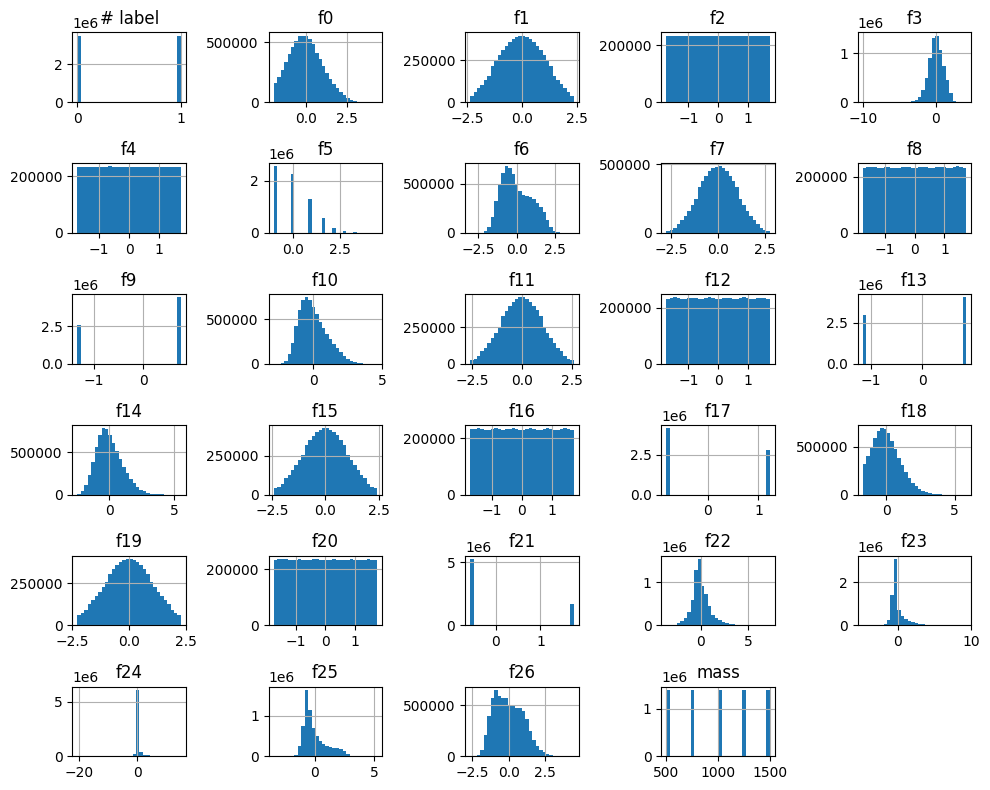

In [ ]:
# Other than mass the data already look scaled
converted_data.hist(bins=30, figsize=(10, 8))
plt.tight_layout()
plt.show()

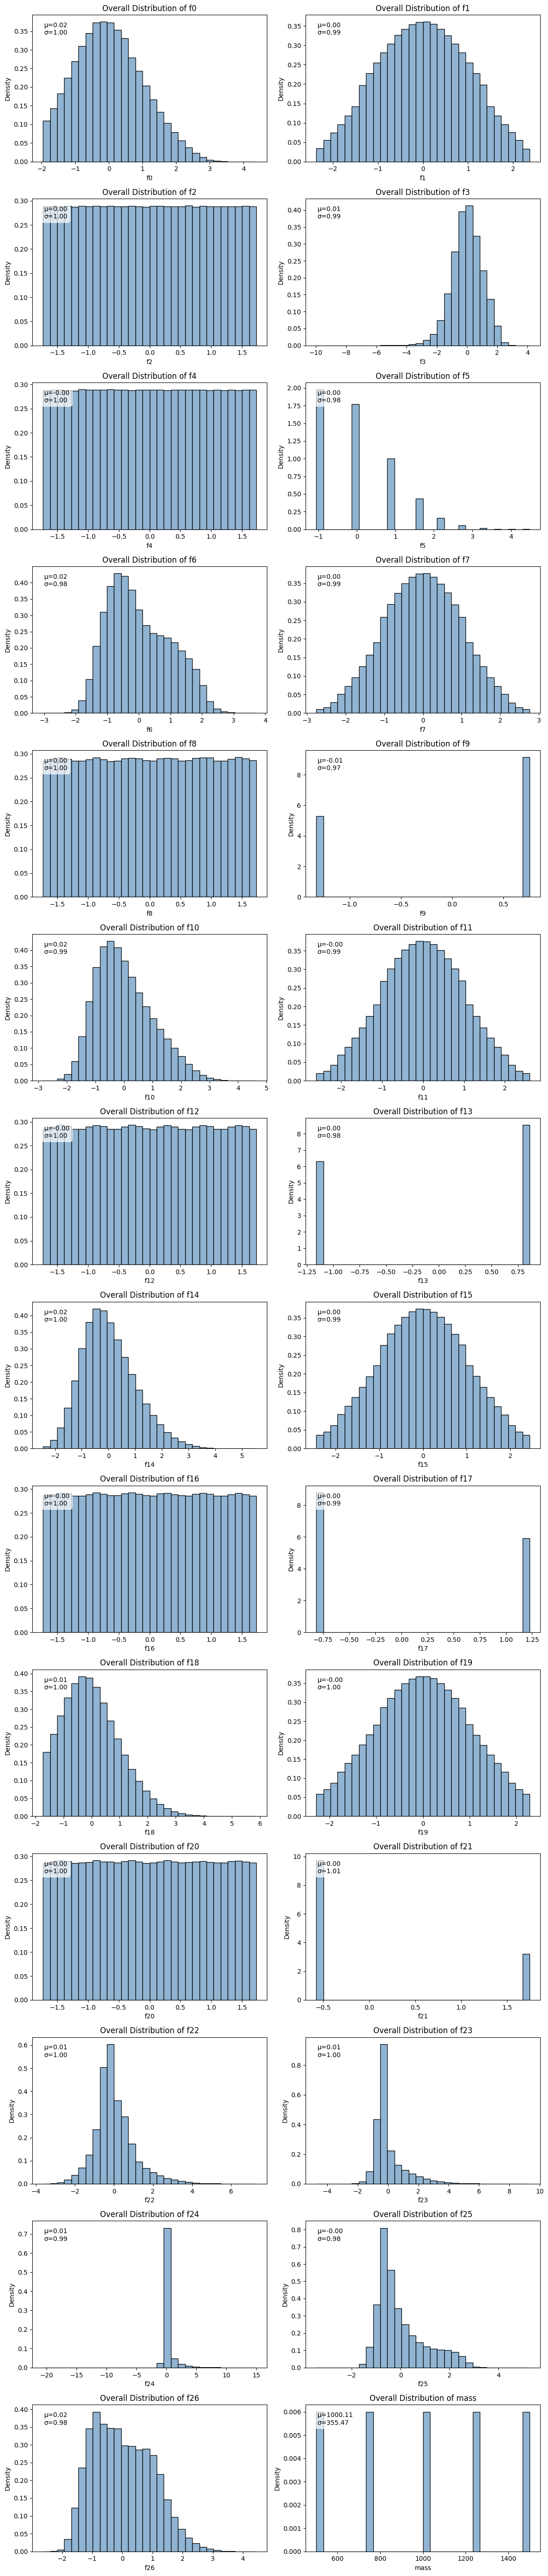

In [ ]:
# Prepare for plotting
plot_features_df = converted_data.copy()
plot_features_df = plot_features_df.drop(columns='# label')
cols_to_plot = plot_features_df.columns

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    data = plot_features_df[col]
    mean = data.mean()
    std = data.std()

    sns.histplot(data=plot_features_df, x=col, bins=30, stat='density',
                 color='steelblue', alpha=0.6, ax=ax)

    ax.text(0.05, 0.95, f"μ={mean:.2f}\nσ={std:.2f}",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='white', alpha=0.7))

    ax.set_title(f"Overall Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

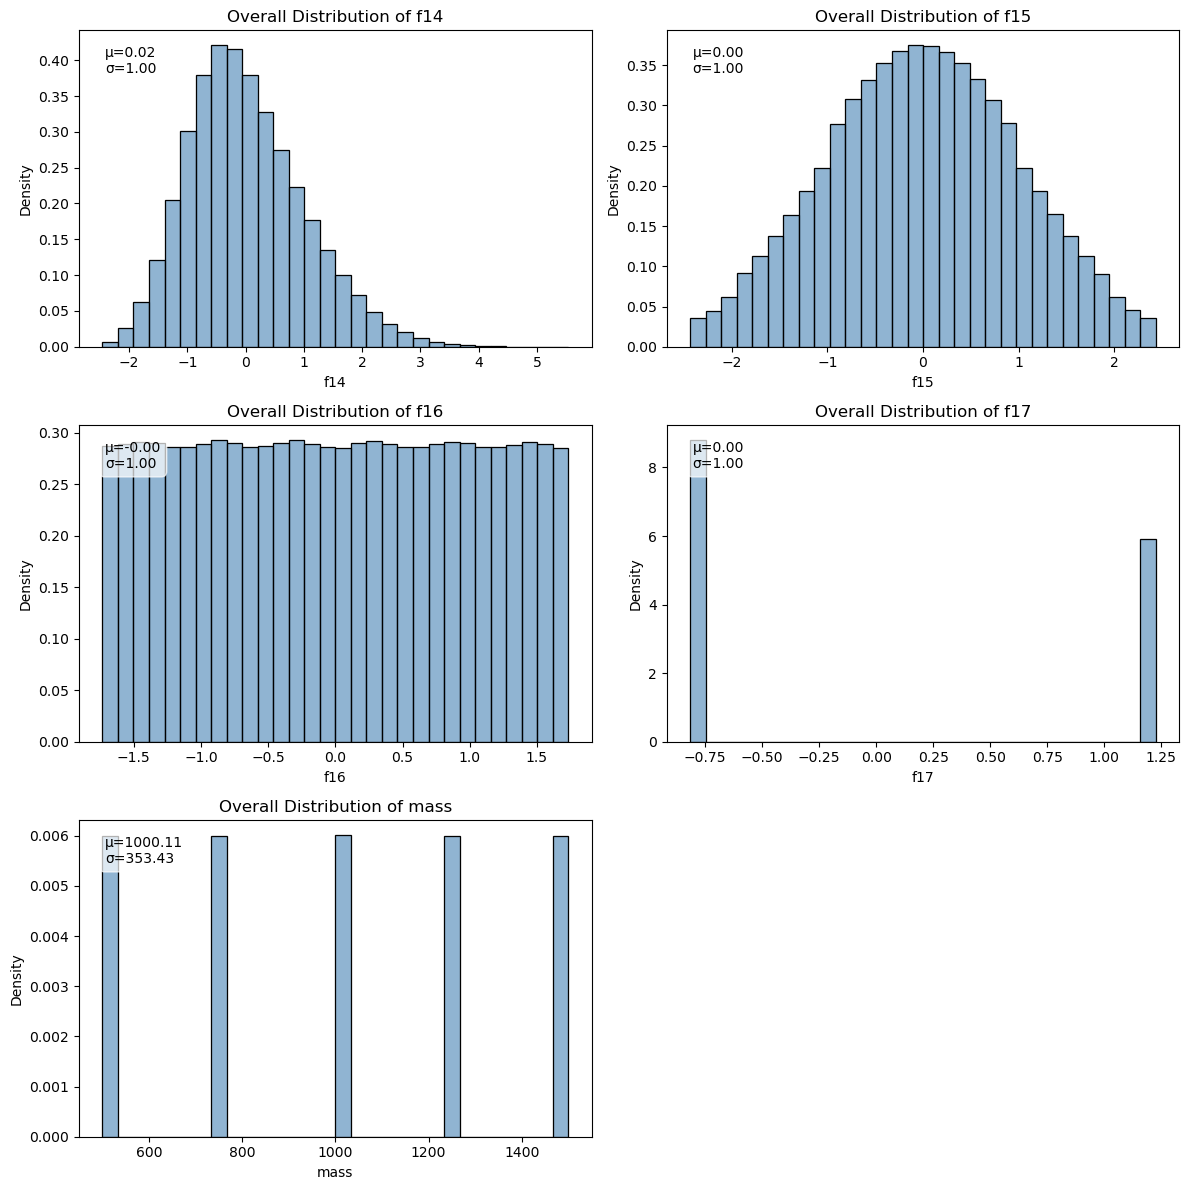

In [7]:
# Prepare for plotting
plot_features_df = converted_data.copy()
plot_features_df = plot_features_df.drop(columns='# label')
cols_to_plot = ['f14', 'f15', 'f16', 'f17', 'mass']

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    data = plot_features_df[col]
    mean = data.mean()
    std = data.std()

    sns.histplot(data=plot_features_df, x=col, bins=30, stat='density',
                 color='steelblue', alpha=0.6, ax=ax)

    ax.text(0.05, 0.95, f"μ={mean:.2f}\nσ={std:.2f}",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='white', alpha=0.7))

    ax.set_title(f"Overall Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

All the features look like they were already scaled with `StandardScaler()` or something equivalent, because the means are 0 and standard deviations are 1. Mass needs to be scaled and it won't hurt to scale the others just in case.

In [8]:

# Find the proportion of each response class
print(converted_data['# label'].value_counts()/converted_data['# label'].count())

# label
1.0    0.500126
0.0    0.499874
Name: count, dtype: float64


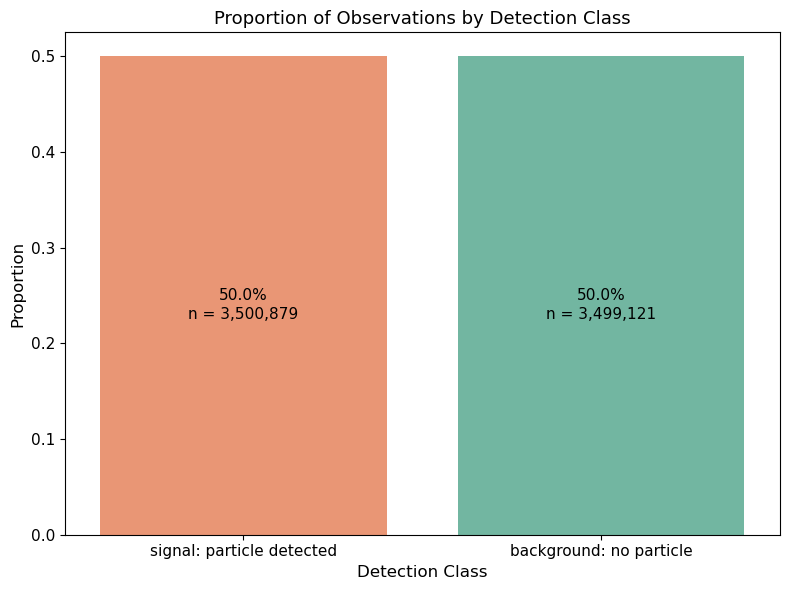

In [9]:
# Set the color palette
palette = sns.color_palette("Set2", n_colors=len(converted_data['# label'].unique()))[::-1]

# Calculate counts and proportions of each category
class_counts = converted_data['# label'].value_counts(sort=False)  # Counts
class_proportions = class_counts / class_counts.sum()  # Proportions

label_map = {0: 'background: no particle', 1: 'signal: particle detected'}

# Create a DataFrame for plotting with proper labels
plot_df = pd.DataFrame({
    'class_label': class_counts.index.map(label_map),
    'proportion': class_proportions.values,
    'count': class_counts.values
})

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    x='class_label',
    y='proportion',
    data=plot_df,
    palette=palette,
    hue='class_label',
    ax=ax
)

# Remove the legend (redundant with x-axis labels)
ax.get_legend().remove() if ax.get_legend() else None

# Add titles and labels with larger font sizes
ax.set_title('Proportion of Observations by Detection Class', fontsize=13)
ax.set_xlabel('Detection Class', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)

# Optional: increase tick label font size too
ax.tick_params(axis='both', labelsize=11)

# Threshold below which the label will be placed *above* the bar
threshold = 0.05  # Adjust as needed based on your data

for i, (bar, count) in enumerate(zip(ax.patches, plot_df['count'])):
    height = bar.get_height()
    percentage = plot_df['proportion'].iloc[i] * 100

    # Percentage label: inside if tall enough, else above
    if height > threshold:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{percentage:.1f}%',
            ha='center', va='center',
            fontsize=11,
            color='black'
        )
            # Count label on top
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2 - 0.02,
            f'n = {count:,}',
            ha='center', va='center',
            fontsize=11
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.025,
            f'{percentage:.1f}%',
            ha='center', va='bottom',
            fontsize=11,
            color='black'
        )
            # Count label on top
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'n = {count:,}',
            ha='center', va='bottom',
            fontsize=11
        )

plt.tight_layout()
plt.show()

## Create X and y, train and validation sets, and scale the X data

In [ ]:
# Make X and y
X = converted_data.drop(columns='# label')
y = converted_data['# label']

# Split first into 80/20 training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, stratify=y, random_state=SEED)

# Fit scaler only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5600000, 28), (1400000, 28), (5600000,), (1400000,))

There are 28 features, so 28 inputs to the first layer.

### Choosing an activation function

Here is some information to consider for choosing an activation function.

**ReLU (Rectified Linear Unit)**

The ReLU function is defined as:

$$
\text{ReLU}(x) = \max(0, x)
$$

It sets all negative values to zero and keeps positive values unchanged. While it is computationally efficient and widely used, it can suffer from the "dying ReLU" problem—neurons can get stuck outputting zero and stop learning.


**Leaky ReLU**

To address the issue of inactive neurons, Leaky ReLU allows a small, non-zero gradient when the input is negative:

$$
\text{LeakyReLU}(x) =
\begin{cases}
x, & \text{if } x \geq 0 \\
\alpha x, & \text{if } x < 0
\end{cases}
$$

Where \( \alpha \) is a small constant (commonly 0.01). This helps keep gradients alive even for negative inputs.


**GELU (Gaussian Error Linear Unit)**

GELU is a smooth, non-monotonic activation function defined as:

$$
\text{GELU}(x) = x \cdot \Phi(x)
$$

Where \( \Phi(x) \) is the standard normal cumulative distribution function. Unlike ReLU, GELU weights inputs by their "importance" (probabilistically), and has been shown to outperform ReLU in deep networks like BERT. It provides a smoother activation curve, which can lead to better convergence and performance in deeper models.


**SiLU (Sigmoid Linear Unit, a.k.a. Swish)**

SiLU is defined as:

$$
\text{SiLU}(x) = x \cdot \sigma(x)
$$

Where \( \sigma(x) \) is the sigmoid function. SiLU is a smooth, differentiable alternative to ReLU that retains some negative input information. It has been used in modern architectures like EfficientNet and often performs better than ReLU or Leaky ReLU in deep neural networks.

> I will start with GELU and if it is too computationally intensive try Leaky ReLU. I will perhaps try SiLU as a backup.

## Cross-Model Setup

In [ ]:
# Get data into the model: Data wrapper class
'''
This classe defines how the input data (X) and target labels (y) are wrapped into a PyTorch-compatible format and returned one sample at a time. It enables the use of DataLoader for batching and shuffling.
'''
class HepmassDataset(Dataset):
    '''
    A custom dataset wrapper class that allows you to define how your data is:
      - stored
      - indexed (__getitem__)
      - returned in batches by a DataLoader
    It wraps the raw data into tensors for PyTorch to understand.
    '''
    def __init__(self, X_dataFrame, y_dataFrame, transform=None, target_transform=None):
        self.X = X_dataFrame
        self.y = y_dataFrame.squeeze().astype("float32") # Remove extra dimensions if needed
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return self.X.shape[0] # Returns the number of samples

    def __getitem__(self, idx):
        # Convert one row of X and its corresponding label y to tensors
        # inputs = torch.tensor(self.X.iloc[idx,:]).float()
        # targets = torch.tensor(self.y.iloc[idx])
        # inputs = torch.tensor(self.X.iloc[idx].values).float()
        # target = torch.tensor(self.y.iloc[idx]).float()
        inputs = torch.tensor(self.X[idx]).float()
        target = torch.tensor(self.y[idx]).float()
        if self.transform:
            inputs = self.transform(inputs)
        if self.target_transform:
            # was targets = self.target_transform(target)
            target = self.target_transform(target)
        return inputs, target


In [ ]:
'''
Initializes training and validation sets using the custom dataset class and prints one example from the training set to ensure that inputs and labels are correctly formatted.
'''
# Dataset
train_data = HepmassDataset(X_train,y_train)
valid_data = HepmassDataset(X_test,y_test)

# Sanity check for data format
for data_in, target in train_data:
    print(data_in)
    print(target)
    break

tensor([ 9.9120e-01, -7.1990e-01, -1.5723e+00, -9.2744e-01,  1.0072e+00,
        -5.9836e-03,  2.6473e-01, -2.4710e+00, -1.7037e-02, -1.3258e+00,
         2.4686e-01, -6.4484e-01,  1.4558e+00, -1.1619e+00, -1.1002e+00,
        -3.3242e-01, -4.1267e-01,  1.2263e+00, -4.5718e-01, -1.5402e+00,
        -1.2281e-01,  1.7431e+00,  5.7330e-01, -7.9196e-01,  2.9326e-01,
        -6.5677e-01,  7.1732e-02,  1.2500e+03])
tensor(0.)


In [ ]:
# Create dataloaders
'''
Defines how the dataset is split into batches and fed to the model.
- batch_size=1024 sets how many samples are in each batch.
- shuffle=True randomizes training batches each epoch, which improves generalization.
- shuffle=False is used for validation/testing to ensure consistent evaluation.
'''

if colab:
    train_dataloader = DataLoader(train_data, batch_size=1024, shuffle=True,num_workers=11)
    test_dataloader = DataLoader(valid_data, batch_size=1024, shuffle=False,num_workers=11)
else:
    train_dataloader = DataLoader(train_data, batch_size=1024, shuffle=True,num_workers=0)
    test_dataloader = DataLoader(valid_data, batch_size=1024, shuffle=False,num_workers=0)

In [ ]:
# Setup early stopping
'''
Monitors the validation accuracy during training and stops early if the model stops improving.
- monitor="val_accuracy": The metric to track.
- mode="max": Trying to maximize accuracy.
- patience=5: Training stops if there's no improvement in validation accuracy for 5 consecutive epochs.
- Since min_delta is not specified, it defaults to 0, meaning any improvement resets the patience counter.
'''

early_stop_callback = EarlyStopping(
    monitor="val_accuracy",  # Metric to monitor (must be logged in `validation_step`)
    mode="max",              # "min" for loss, "max" for accuracy
    patience=5,              # Number of epochs with no improvement before stopping
    verbose=True
)

In [ ]:
# To clear checkpoints so models run independently
def clear_checkpoints(model_name):
    """Clear all checkpoints for a specific model to ensure fresh training"""
    pattern = f"logs/{model_name}*/**/*.ckpt"
    ckpts = glob.glob(pattern, recursive=True)
    for f in ckpts:
        print(f"Deleting: {f}")
        os.remove(f)
    print(f"Cleared {len(ckpts)} checkpoints for {model_name}")

In [12]:
# For each model's logger
if colab:
    logs_dir = os.path.join(base_path, "logs")  # Saves to Google Drive
else:
    logs_dir = "logs"  # Saves locally in current directory


## Make Base Network

I will start with a baseline network with 1 layer of 100 neurons, using GELU.

In [ ]:
# Build the base network with logits output (put sigmoid to convert into probabilities in the loss)
class MyBaseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        The init and forward class functions are part of every Network.
        If no activation for the final layer, use nn.BCEWithLogitsLoss,
        which combines combines a Sigmoid layer and the BCELoss in a single class.
        Therefore, you need to give the loss functions raw logits.
        This is supposed to be more stable, but I had trouble making sure I was squeezing the correct data form.
        '''
        self.model = nn.Sequential(
            nn.Linear(28, 100),
            nn.GELU(),
            nn.Linear(100, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        outputs = self.model(x)
        return outputs

In [ ]:
# Lightning Module
class BaseModel(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = MyBaseNetwork()
        self.loss = nn.BCELoss()  # or BCEWithLogitsLoss() without sigmoid added to output layer

    def forward(self,x):
        y_hat = self.model(x)
        return y_hat

    def training_step(self, batch, batch_idx):
        # training_step defines the train loop
        # it is independent of forward
        # x, y = batch
        # y_hat = self.model(x)
        # loss = self.loss(y_hat, y.float())
        # # logging to TensorBoard by default
        # self.log("train_loss", loss)
        # return loss
        x, y = batch
        # Remove the trailing dimension (e.g., [batch_size, 1] → [batch_size])
        # so that the predicted output matches the shape of the target labels
        y_hat = self.model(x).squeeze()

        loss = self.loss(y_hat, y)
        acc = (y_hat.round() == y).float().mean()
        # logging to csv_log
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_accuracy", acc, prog_bar=True)

        return {"loss": loss, "train_accuracy": acc}  # loss key is required

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()

        loss = self.loss(y_hat, y)
        # Lightning defaults to on_step=False, on_epoch=True for metrics logged in validation_step,
        # so this manually calculated batch accuracy will be averaged across all validation batches.
        # This ensures val_accuracy is logged per epoch and used correctly by EarlyStopping.
        # In the future, consider using torchmetrics:
        #   self.val_acc = torchmetrics.Accuracy(task="binary")
        #   self.val_acc.update(preds, y)  (in validation_step)
        #   self.log("val_accuracy", self.val_acc.compute(), on_epoch=True)  (in on_validation_epoch_end)

        acc = (y_hat.round() == y).float().mean()
        # logging to csv_log
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_accuracy", acc, prog_bar=True)

        return {"val_loss": loss, "val_accuracy": acc}

    # Added after initial training
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat, y

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

In [ ]:
# Instantiate and train
# Specify a unique version for each model run
clear_checkpoints("base_model")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_log = CSVLogger(save_dir=logs_dir, name="base_model", version=timestamp)
base_model = BaseModel()

trainer = pl.Trainer(max_epochs=1000, logger=csv_log, callbacks=[early_stop_callback], accelerator="auto", log_every_n_steps=100)  # accelerator="gpu"

# Time it
start = time.time()
trainer.fit(base_model, train_dataloader, test_dataloader, ckpt_path=None)
# specify ckpt_path=None to force starting from scratch
end = time.time()

print(f"\nTraining completed in {(end - start)/60:.2f} minutes.")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Cleared 0 checkpoints for base_model


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type          | Params | Mode 
------------------------------------------------
0 | model | MyBaseNetwork | 3.0 K  | train
1 | loss  | BCELoss       | 0      | train
------------------------------------------------
3.0 K     Trainable params
0         Non-trainable params
3.0 K     Total params
0.012     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type          | Params | Mode 
------------------------------------------------
0 | model | MyBaseNetwork | 3.0 K  | train
1 | loss  | BCELoss       | 0      | train
------------------------------------------------
3.0 K     Trainable params
0         Non-trainable params
3.0 K     Total params
0.012     Total estimated model params size (MB)
7         Modules in train mode
0    

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.864. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.864. Signaling Trainer to stop.



Training completed in 46.50 minutes.


## 5-Layer Network

I'll increase to 5 layers of 1000 neurons each, still using GELU. I need to decrease the learning rate, because with 1e-3 the loss is very high because the probabilities are all close to .5.

In [ ]:
# Setup early stopping for each model because the checkpoint history is getting inherited
# For dense model (create a fresh one)
dense_early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    verbose=True
)

In [ ]:
# Build the base network with probabilities output using sigmoid activation
class MyDenseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        The init and forward class functions are part of every Network.
        '''
        self.model = nn.Sequential(
            nn.Linear(28, 1000),
            nn.GELU(),
            nn.Linear(1000, 1000),
            nn.GELU(),
            nn.Linear(1000, 1000),
            nn.GELU(),
            nn.Linear(1000, 1000),
            nn.GELU(),
            nn.Linear(1000, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        outputs = self.model(x)
        return outputs

In [ ]:
# Lightning Module
class DenseModel(pl.LightningModule):
    """
    A PyTorch Lightning module for binary classification using a dense neural network.

    This module wraps:
    - A fully connected feedforward network (`MyDenseNetwork`) with sigmoid output
    - Binary cross-entropy loss (`nn.BCELoss`) for training
    - Accuracy calculation using a 0.5 threshold on predicted probabilities
    - Logging of training and validation loss and accuracy to the configured logger

    Optimization details:
    - Uses the Adam optimizer with a fixed learning rate
    - Gradients are automatically computed (`loss.backward()`), optionally clipped,
      used to update weights (`optimizer.step()`), and zeroed out after each step
      (`optimizer.zero_grad()`), all handled by Lightning

    The model is trained in mini-batches, with one weight update per batch.
    The loss returned from `training_step` is used by Lightning to manage
    backpropagation and optimization.

    This module integrates seamlessly with callbacks like early stopping.
    """
    def __init__(self):
        super().__init__()
        self.model = MyDenseNetwork()
        self.loss = nn.BCELoss()  # or BCEWithLogitsLoss() without sigmoid added to output layer

    def forward(self,x):
        y_hat = self.model(x)
        return y_hat

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()  # Already passed through Sigmoid

        # DEBUG: Check output range and target
        # Print once at the very first step only
        if self.global_step == 0 and batch_idx == 0:
            print(f"[Debug] y_hat: min={y_hat.min().item():.4f}, max={y_hat.max().item():.4f}")
            print(f"[Debug] y: dtype={y.dtype}, unique={y.unique()}")
        loss = self.loss(y_hat, y)

        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_accuracy", acc, prog_bar=True)

        return {"loss": loss, "train_accuracy": acc}  # loss key is required

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()
        loss = self.loss(y_hat, y)
        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_accuracy", acc, prog_bar=True)

        return {"val_loss": loss, "val_accuracy": acc}

    # Added after initial training
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat, y

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4) # outputs were squished near .5 so model wasn't learning
        return optimizer

In [ ]:
# Instantiate and train
# Specify a unique version for each model run
clear_checkpoints("dense_model")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_log = CSVLogger(save_dir=logs_dir, name="dense_model", version=timestamp)
dense_model = DenseModel()

trainer = pl.Trainer(max_epochs=1000, logger=csv_log, callbacks=[dense_early_stop], accelerator="auto", log_every_n_steps=100)  # accelerator="gpu"

# Time it
start = time.time()
trainer.fit(dense_model, train_dataloader, test_dataloader, ckpt_path=None) # Force trainer to ignore any checkpoint
end = time.time()

print(f"\nTraining completed in {(end - start)/60:.2f} minutes.")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type        

Cleared 0 checkpoints for dense_model


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

[Debug] y_hat: min=0.8096, max=0.9899
[Debug] y: dtype=torch.float32, unique=tensor([0., 1.], device='cuda:0')


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.882. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.882. Signaling Trainer to stop.



Training completed in 78.03 minutes.


## Model with Dropouts

Now I'll add .2 dropouts after every activation.


In [15]:
# Early stopping for dropout model (create a fresh one)
dropout_early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    verbose=True
)

In [ ]:
# Model with dropouts
class MyDropoutNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        The init and forward class functions are part of every Network.
        '''
        self.model = nn.Sequential(
            nn.Linear(28, 1000),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        outputs = self.model(x)
        return outputs

In [ ]:
# Lightning Module
class DropoutModel(pl.LightningModule):
    """
    A PyTorch Lightning module for binary classification using a dense neural network.

    This module wraps:
    - A fully connected feedforward network (`MyDenseNetwork`) with sigmoid output
    - Binary cross-entropy loss (`nn.BCELoss`) for training
    - Accuracy calculation using a 0.5 threshold on predicted probabilities
    - Logging of training and validation loss and accuracy to the configured logger

    Optimization details:
    - Uses the Adam optimizer with a fixed learning rate
    - Gradients are automatically computed (`loss.backward()`), optionally clipped,
      used to update weights (`optimizer.step()`), and zeroed out after each step
      (`optimizer.zero_grad()`), all handled by Lightning

    The model is trained in mini-batches, with one weight update per batch.
    The loss returned from `training_step` is used by Lightning to manage
    backpropagation and optimization.

    This module integrates seamlessly with callbacks like early stopping.
    """
    def __init__(self):
        super().__init__()
        self.model = MyDropoutNetwork()
        self.loss = nn.BCELoss()  # or BCEWithLogitsLoss() without sigmoid added to output layer

    def forward(self,x):
        y_hat = self.model(x)
        return y_hat

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()  # Already passed through Sigmoid

        # DEBUG: Check output range and target
        # Print once at the very first step only
        if self.global_step == 0 and batch_idx == 0:
            print(f"[Debug] y_hat: min={y_hat.min().item():.4f}, max={y_hat.max().item():.4f}")
            print(f"[Debug] y: dtype={y.dtype}, unique={y.unique()}")
        loss = self.loss(y_hat, y)

        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_accuracy", acc, prog_bar=True)

        return {"loss": loss, "train_accuracy": acc}  # loss key is required

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()
        loss = self.loss(y_hat, y)
        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_accuracy", acc, prog_bar=True)

        return {"val_loss": loss, "val_accuracy": acc}

    # Added after initial training
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat, y

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4) # outputs were squished near .5 so model wasn't learning
        return optimizer

In [ ]:
# Instantiate and train
# Specify a unique version for each model run
clear_checkpoints("dropout_model")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_log = CSVLogger(save_dir=logs_dir, name="dropout_model", version=timestamp)
dropout_model = DropoutModel()

trainer = pl.Trainer(max_epochs=1000, logger=csv_log, callbacks=[dropout_early_stop], accelerator="auto", log_every_n_steps=100)  # accelerator="gpu"

# Time it
start = time.time()
trainer.fit(dropout_model, train_dataloader, test_dataloader, ckpt_path=None) # Force trainer to ignore any checkpoint
end = time.time()

print(f"\nTraining completed in {(end - start)/60:.2f} minutes.")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Cleared 0 checkpoints for dropout_model


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MyDropoutNetwork | 3.0 M  | train
1 | loss  | BCELoss          | 0      | train
---------------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.132    Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MyDropoutNetwork | 3.0 M  | train
1 | loss  | BCELoss          | 0      | train
---------------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.132    Total estimated model params size (MB)
17     

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.885. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.885. Signaling Trainer to stop.



Training completed in 67.41 minutes.


## Try other activations in a deep network:
### LeakyReLu

In [ ]:
# Early stopping for leaky model (create a fresh one)
leaky_early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    verbose=True
)

In [ ]:
class MyLeakyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        The init and forward class functions are part of every Network.
        '''
        self.model = nn.Sequential(
            nn.Linear(28, 1000),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        outputs = self.model(x)
        return outputs

In [ ]:
# Lightning Module
class LeakyModel(pl.LightningModule):
    """
    A PyTorch Lightning module for binary classification using a dense neural network.

    This module wraps:
    - A fully connected feedforward network (`MyDenseNetwork`) with sigmoid output
    - Binary cross-entropy loss (`nn.BCELoss`) for training
    - Accuracy calculation using a 0.5 threshold on predicted probabilities
    - Logging of training and validation loss and accuracy to the configured logger

    Optimization details:
    - Uses the Adam optimizer with a fixed learning rate
    - Gradients are automatically computed (`loss.backward()`), optionally clipped,
      used to update weights (`optimizer.step()`), and zeroed out after each step
      (`optimizer.zero_grad()`), all handled by Lightning

    The model is trained in mini-batches, with one weight update per batch.
    The loss returned from `training_step` is used by Lightning to manage
    backpropagation and optimization.

    This module integrates seamlessly with callbacks like early stopping.
    """
    def __init__(self):
        super().__init__()
        self.model = MyLeakyNetwork()
        self.loss = nn.BCELoss()  # or BCEWithLogitsLoss() without sigmoid added to output layer

    def forward(self,x):
        y_hat = self.model(x)
        return y_hat

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()  # Already passed through Sigmoid

        # DEBUG: Check output range and target
        # Print once at the very first step only
        if self.global_step == 0 and batch_idx == 0:
            print(f"[Debug] y_hat: min={y_hat.min().item():.4f}, max={y_hat.max().item():.4f}")
            print(f"[Debug] y: dtype={y.dtype}, unique={y.unique()}")
        loss = self.loss(y_hat, y)

        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_accuracy", acc, prog_bar=True)

        return {"loss": loss, "train_accuracy": acc}  # loss key is required

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()
        loss = self.loss(y_hat, y)
        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_accuracy", acc, prog_bar=True)

        return {"val_loss": loss, "val_accuracy": acc}

    # Added after initial training
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat, y

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4) # outputs were squished near .5 so model wasn't learning
        return optimizer

In [ ]:
# Instantiate and train
# Specify a unique version for each model run
clear_checkpoints("leaky_model")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_log = CSVLogger(save_dir=logs_dir, name="leaky_model", version=timestamp)
leaky_model = LeakyModel()

trainer = pl.Trainer(max_epochs=1000, logger=csv_log, callbacks=[leaky_early_stop], accelerator="auto", log_every_n_steps=100)  # accelerator="gpu"

# Time it
start = time.time()
trainer.fit(leaky_model, train_dataloader, test_dataloader, ckpt_path=None) # Force trainer to ignore any checkpoint
end = time.time()

print(f"\nTraining completed in {(end - start)/60:.2f} minutes.")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Cleared 0 checkpoints for leaky_model


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type           | Params | Mode 
-------------------------------------------------
0 | model | MyLeakyNetwork | 3.0 M  | train
1 | loss  | BCELoss        | 0      | train
-------------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.132    Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type           | Params | Mode 
-------------------------------------------------
0 | model | MyLeakyNetwork | 3.0 M  | train
1 | loss  | BCELoss        | 0      | train
-------------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.132    Total estimated model params size (MB)
17        Modules in train 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.884. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.884. Signaling Trainer to stop.



Training completed in 72.15 minutes.


### Swish (SiLU)

This on is supposed to be good for deep networks.

In [ ]:
# Early stopping for swish model (create a fresh one)
swish_early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    verbose=True
)

In [ ]:
class MySwishNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        The init and forward class functions are part of every Network.
        '''
        self.model = nn.Sequential(
            nn.Linear(28, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        outputs = self.model(x)
        return outputs

In [ ]:
# Lightning Module
class SwishModel(pl.LightningModule):
    """
    A PyTorch Lightning module for binary classification using a dense neural network.

    This module wraps:
    - A fully connected feedforward network (`MyDenseNetwork`) with sigmoid output
    - Binary cross-entropy loss (`nn.BCELoss`) for training
    - Accuracy calculation using a 0.5 threshold on predicted probabilities
    - Logging of training and validation loss and accuracy to the configured logger

    Optimization details:
    - Uses the Adam optimizer with a fixed learning rate
    - Gradients are automatically computed (`loss.backward()`), optionally clipped,
      used to update weights (`optimizer.step()`), and zeroed out after each step
      (`optimizer.zero_grad()`), all handled by Lightning

    The model is trained in mini-batches, with one weight update per batch.
    The loss returned from `training_step` is used by Lightning to manage
    backpropagation and optimization.

    This module integrates seamlessly with callbacks like early stopping.
    """
    def __init__(self):
        super().__init__()
        self.model = MySwishNetwork()
        self.loss = nn.BCELoss()  # or BCEWithLogitsLoss() without sigmoid added to output layer

    def forward(self,x):
        y_hat = self.model(x)
        return y_hat

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()  # Already passed through Sigmoid

        # DEBUG: Check output range and target
        # Print once at the very first step only
        if self.global_step == 0 and batch_idx == 0:
            print(f"[Debug] y_hat: min={y_hat.min().item():.4f}, max={y_hat.max().item():.4f}")
            print(f"[Debug] y: dtype={y.dtype}, unique={y.unique()}")
        loss = self.loss(y_hat, y)

        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_accuracy", acc, prog_bar=True)

        return {"loss": loss, "train_accuracy": acc}  # loss key is required

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()
        loss = self.loss(y_hat, y)
        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_accuracy", acc, prog_bar=True)

        return {"val_loss": loss, "val_accuracy": acc}

    # Added after initial training
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat, y

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4) # outputs were squished near .5 so model wasn't learning
        return optimizer

In [ ]:
# Instantiate and train
# Specify a unique version for each model run
clear_checkpoints("swish_model")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_log = CSVLogger(save_dir=logs_dir, name="swish_model", version=timestamp)
swish_model = SwishModel()

trainer = pl.Trainer(max_epochs=1000, logger=csv_log, callbacks=[swish_early_stop], accelerator="auto", log_every_n_steps=100)  # accelerator="gpu"

# Time it
start = time.time()
trainer.fit(swish_model, train_dataloader, test_dataloader, ckpt_path=None) # Force trainer to ignore any checkpoint
end = time.time()

print(f"\nTraining completed in {(end - start)/60:.2f} minutes.")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type        

Cleared 0 checkpoints for swish_model


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

[Debug] y_hat: min=0.0001, max=1.0000
[Debug] y: dtype=torch.float32, unique=tensor([0., 1.], device='cuda:0')


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.886. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.886. Signaling Trainer to stop.



Training completed in 70.54 minutes.


# After deciding on an activation try a learning rate scheduler with AdamW optimizer.

In [ ]:
# Early stopping for swish model (create a fresh one)
lrscheduler_early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    verbose=True
)

In [29]:
# This is the same as the Swish above but I'll rename it just in case.
class LRSchedulerNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        The init and forward class functions are part of every Network.
        '''
        self.model = nn.Sequential(
            nn.Linear(28, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        outputs = self.model(x)
        return outputs

In [30]:
# Lightning Module
class LRSchedulerModel(pl.LightningModule):
    """
    A PyTorch Lightning module for binary classification using a dense neural network.

    This module wraps:
    - A fully connected feedforward network (`MyDenseNetwork`) with sigmoid output
    - Binary cross-entropy loss (`nn.BCELoss`) for training
    - Accuracy calculation using a 0.5 threshold on predicted probabilities
    - Logging of training and validation loss and accuracy to the configured logger

    Optimization details:
    - Uses the Adam optimizer with a fixed learning rate
    - Gradients are automatically computed (`loss.backward()`), optionally clipped,
      used to update weights (`optimizer.step()`), and zeroed out after each step
      (`optimizer.zero_grad()`), all handled by Lightning

    The model is trained in mini-batches, with one weight update per batch.
    The loss returned from `training_step` is used by Lightning to manage
    backpropagation and optimization.

    This module integrates seamlessly with callbacks like early stopping.
    """
    def __init__(self):
        super().__init__()
        self.model = LRSchedulerNetwork()
        self.loss = nn.BCELoss()  # or BCEWithLogitsLoss() without sigmoid added to output layer

    def forward(self,x):
        y_hat = self.model(x)
        return y_hat

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()  # Already passed through Sigmoid

        # DEBUG: Check output range and target
        # Print once at the very first step only
        if self.global_step == 0 and batch_idx == 0:
            print(f"[Debug] y_hat: min={y_hat.min().item():.4f}, max={y_hat.max().item():.4f}")
            print(f"[Debug] y: dtype={y.dtype}, unique={y.unique()}")
        loss = self.loss(y_hat, y)

        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_accuracy", acc, prog_bar=True)

        return {"loss": loss, "train_accuracy": acc}  # loss key is required

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x).squeeze()
        loss = self.loss(y_hat, y)
        y_pred = (y_hat > 0.5).float()
        acc = (y_pred == y).float().mean()
        # logging to csv_log
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_accuracy", acc, prog_bar=True)

        return {"val_loss": loss, "val_accuracy": acc}

    # Added after initial training
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat, y

    def configure_optimizers(self):
      optimizer = torch.optim.AdamW(self.parameters(), lr=1e-4, weight_decay=1e-2)

      # Simple fixed estimate for total steps
      # Based on dataset size of ~7M with 80% training and batch size 1024
      total_steps = len(train_dataloader) * trainer.max_epochs + 1

      scheduler = torch.optim.lr_scheduler.OneCycleLR(
          optimizer,
          max_lr=3e-4,
          total_steps=total_steps,
          pct_start=0.3,
          div_factor=25,
          final_div_factor=10000
      )

      return {
          "optimizer": optimizer,
          "lr_scheduler": {
              "scheduler": scheduler,
              "interval": "step"
        }
    }

In [ ]:
# Instantiate and train
# Specify a unique version for each model run
clear_checkpoints("lrscheduler_model")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_log = CSVLogger(save_dir=logs_dir, name="lrscheduler_model", version=timestamp)
lrscheduler_model = LRSchedulerModel()

trainer = pl.Trainer(max_epochs=1000, logger=csv_log, callbacks=[lrscheduler_early_stop], accelerator="auto", log_every_n_steps=100)  # accelerator="gpu"

# Time it
start = time.time()
trainer.fit(lrscheduler_model, train_dataloader, test_dataloader, ckpt_path=None) # Force trainer to ignore any checkpoint
end = time.time()

print(f"\nTraining completed in {(end - start)/60:.2f} minutes.")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Cleared 0 checkpoints for lrscheduler_model


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type               | Params | Mode 
-----------------------------------------------------
0 | model | LRSchedulerNetwork | 3.0 M  | train
1 | loss  | BCELoss            | 0      | train
-----------------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.132    Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type               | Params | Mode 
-----------------------------------------------------
0 | model | LRSchedulerNetwork | 3.0 M  | train
1 | loss  | BCELoss            | 0      | train
-----------------------------------------------------
3.0 M     Trainable params
0         Non-trainable params
3.0 M     Total params
12.132    Total estimated model para

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.885. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_accuracy did not improve in the last 5 records. Best score: 0.885. Signaling Trainer to stop.



Training completed in 117.63 minutes.


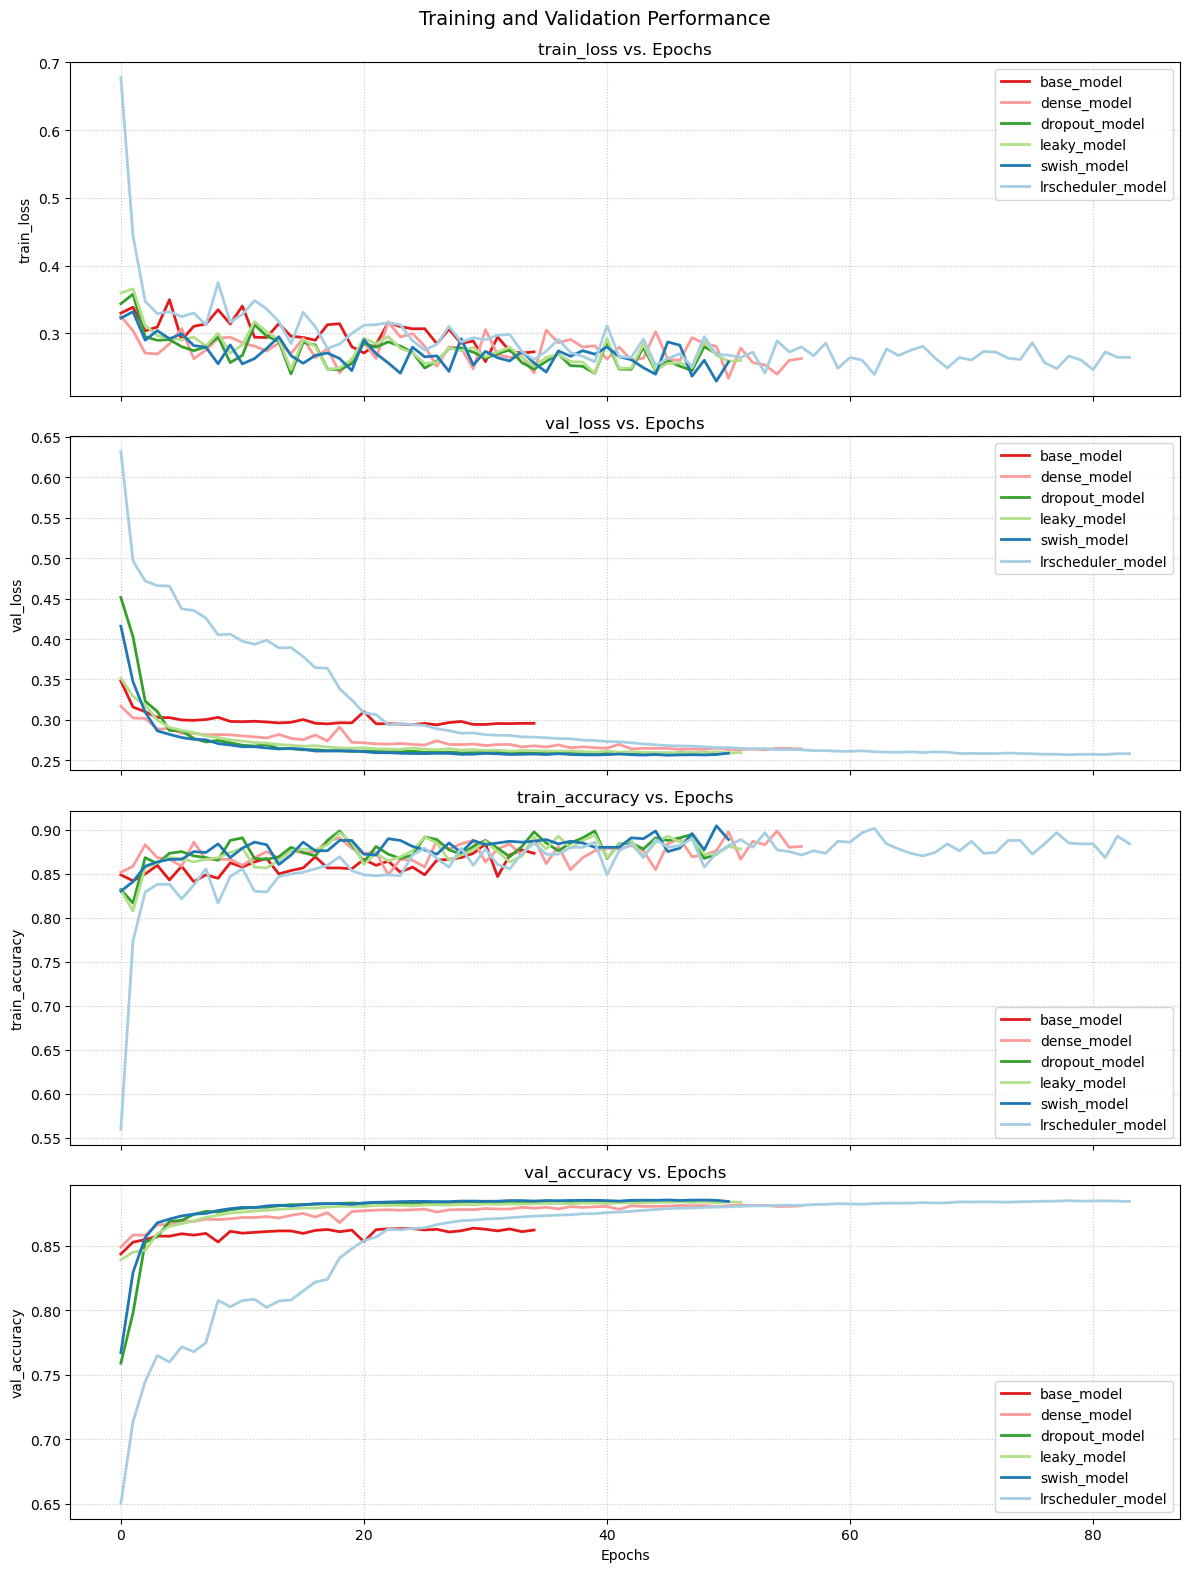

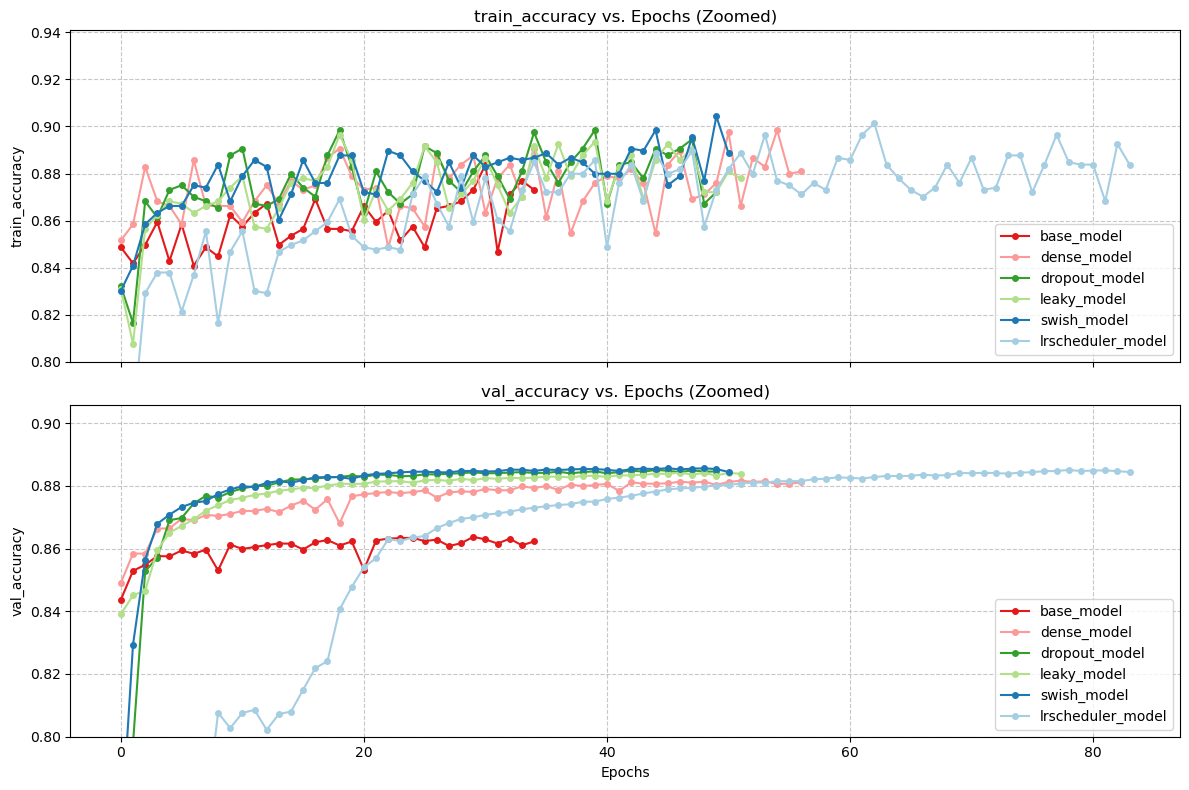

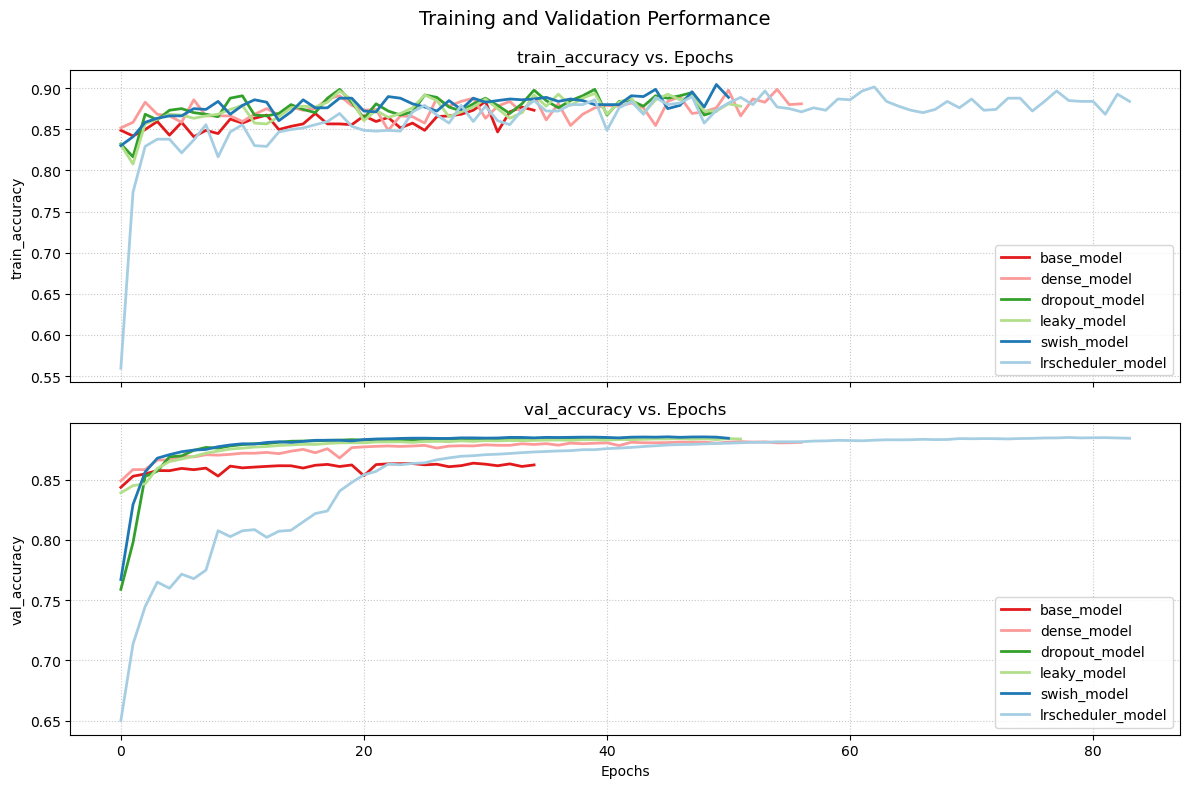

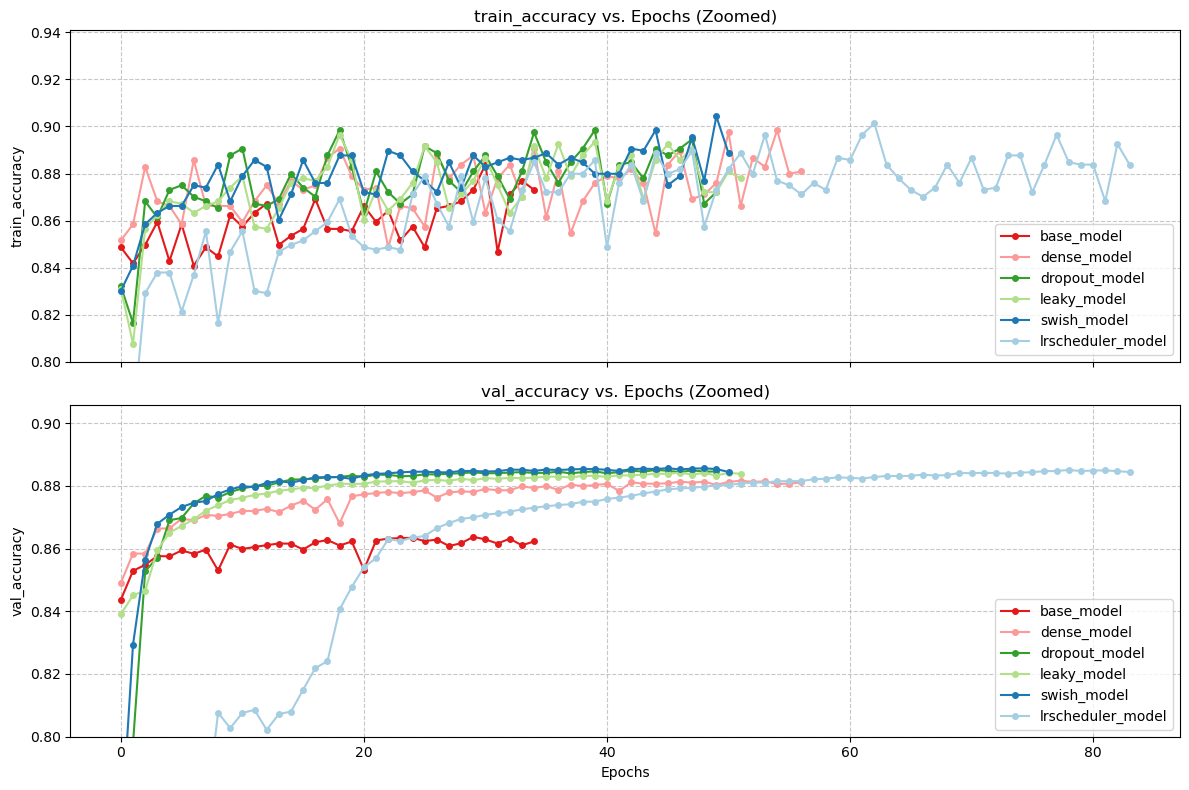

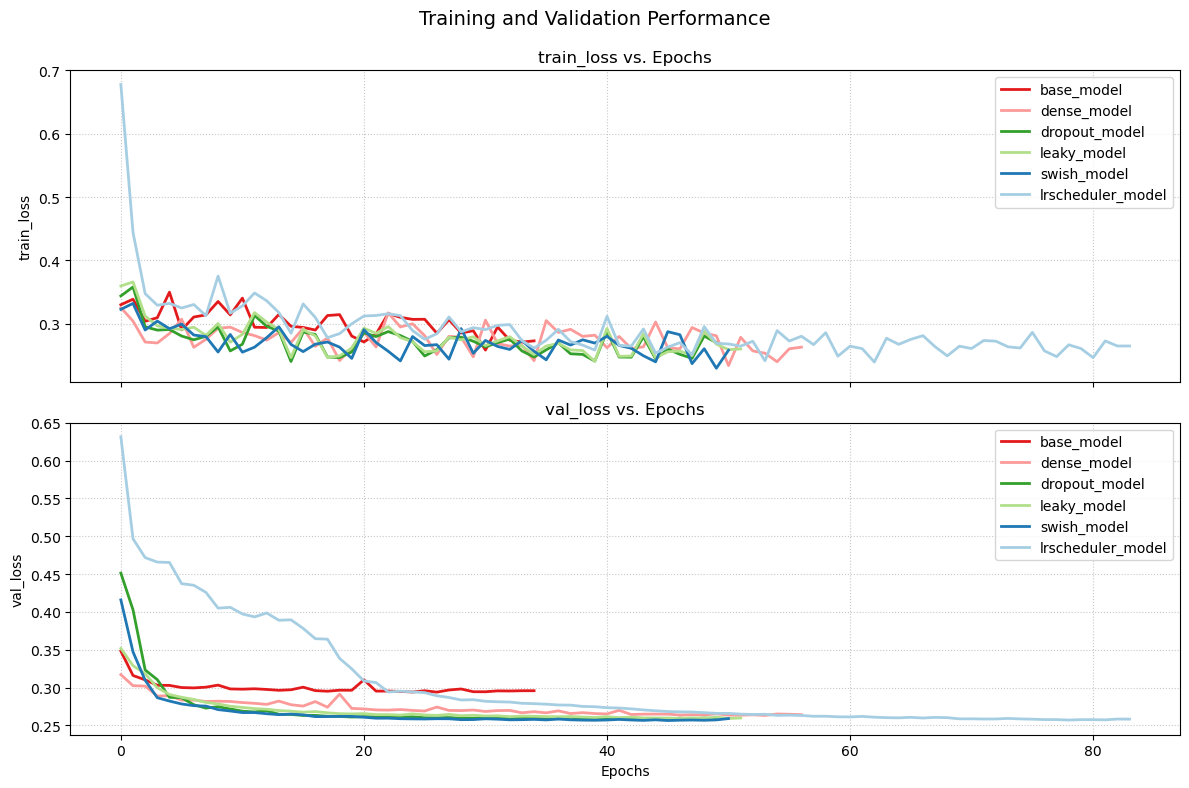

In [ ]:
def load_metrics(model_name, logs_dir="logs"):
    """Load metrics for all versions of a given model"""
    pattern = f"{logs_dir}/{model_name}/**/metrics.csv"
    files = glob.glob(pattern, recursive=True)

    all_data = []
    for file in files:
        # Extract version from path
        version = os.path.basename(os.path.dirname(file))
        df = pd.read_csv(file)
        df['version'] = version
        df['model'] = model_name
        all_data.append(df)

    if all_data:
        return pd.concat(all_data)
    else:
        print(f"No metrics found for {model_name} in {logs_dir}")
        return None

def plot_metrics_comparison(model_names, metric_names=None, logs_dir="logs"):
    """Plot metrics for multiple models for comparison"""
    if metric_names is None:
        metric_names = ['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy']

    # Load data for all models
    all_model_data = []
    for model in model_names:
        data = load_metrics(model, logs_dir)
        if data is not None:
            all_model_data.append(data)

    if not all_model_data:
        print("No metrics data found!")
        return

    combined_data = pd.concat(all_model_data)

    # Create plots
    n_metrics = len(metric_names)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(12, 4*n_metrics), sharex=True)

    if n_metrics == 1:
        axes = [axes]  # Make it iterable if there's only one metric

    colors = plt.cm.tab10.colors
    colors = plt.cm.Paired.colors
    colors = plt.cm.Paired.colors[:6][::-1]  # First 6 colors, reversed

    for i, metric in enumerate(metric_names):
        ax = axes[i]

        for j, model in enumerate(model_names):
            model_data = combined_data[combined_data['model'] == model]
            if model_data.empty or metric not in model_data.columns:
                continue

            # Group by epoch and get the latest step's value for each epoch
            epoch_data = model_data.groupby('epoch')[metric].last().reset_index()

            color = colors[j % len(colors)]
            # ax.plot(epoch_data['epoch'], epoch_data[metric],
            #        marker='o', markersize=4, linestyle='-',
            #        label=f"{model}", color=color)
            ax.plot(epoch_data['epoch'], epoch_data[metric], label=f"{model}", color=color, linewidth=2)

        ax.set_title(f"{metric} vs. Epochs")
        ax.set_ylabel(metric)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend()

    axes[-1].set_xlabel("Epochs")
    fig.suptitle("Training and Validation Performance for All Models", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

    # Also create a zoomed-in version of the accuracy plots to better see differences
    if any('accuracy' in m for m in metric_names):
        acc_metrics = [m for m in metric_names if 'accuracy' in m]
        fig, axes = plt.subplots(len(acc_metrics), 1, figsize=(12, 4*len(acc_metrics)), sharex=True)

        if len(acc_metrics) == 1:
            axes = [axes]

        for i, metric in enumerate(acc_metrics):
            ax = axes[i]

            for j, model in enumerate(model_names):
                model_data = combined_data[combined_data['model'] == model]
                if model_data.empty or metric not in model_data.columns:
                    continue

                epoch_data = model_data.groupby('epoch')[metric].last().reset_index()

                color = colors[j % len(colors)]
                ax.plot(epoch_data['epoch'], epoch_data[metric],
                       marker='o', markersize=4, linestyle='-',
                       label=f"{model}", color=color)

            # Set y-axis limits to zoom in on relevant accuracy range
            y_values = combined_data[metric].dropna()
            if len(y_values) > 0:
                y_min = max(0.8, y_values.min() - 0.02)
                y_max = min(1.0, y_values.max() + 0.02)
                ax.set_ylim(y_min, y_max)

            ax.set_title(f"{metric} vs. Epochs (Zoomed)")
            ax.set_ylabel(metric)
            ax.grid(True, linestyle='--', alpha=0.7)
            ax.legend()

        axes[-1].set_xlabel("Epochs")
        plt.tight_layout()
        plt.show()

# Use the correct logs directory based on environment
if 'google.colab' in str(get_ipython()):
    # We're in Colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    logs_dir = '/content/drive/MyDrive/Colab Notebooks/logs'
else:
    # We're on local machine
    logs_dir = "logs"

# List of models to compare
model_names = ['base_model', 'dense_model', 'dropout_model', 'leaky_model', 'swish_model', 'lrscheduler_model']

# Plot all metrics
plot_metrics_comparison(model_names, logs_dir=logs_dir)

# Plot just the accuracy metrics
plot_metrics_comparison(model_names, ['train_accuracy', 'val_accuracy'], logs_dir=logs_dir)

# Plot just the loss metrics
plot_metrics_comparison(model_names, ['train_loss', 'val_loss'], logs_dir=logs_dir)

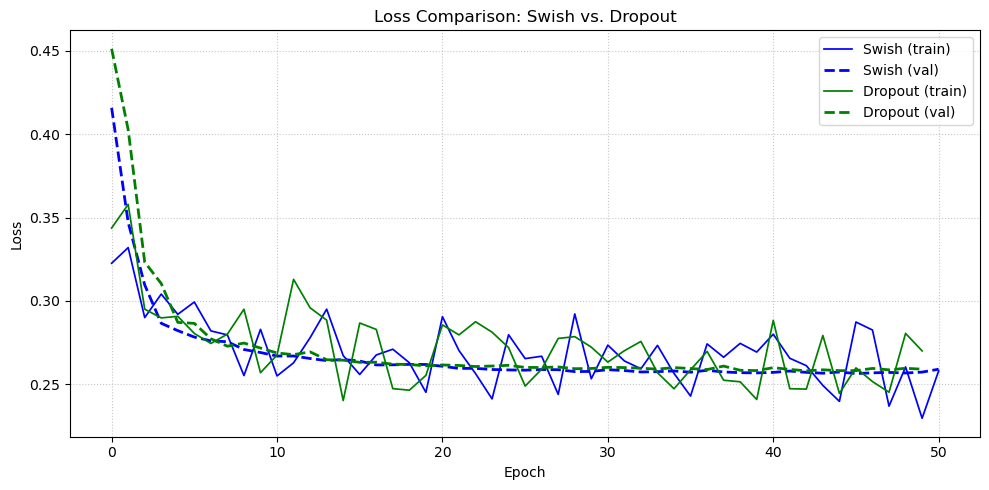

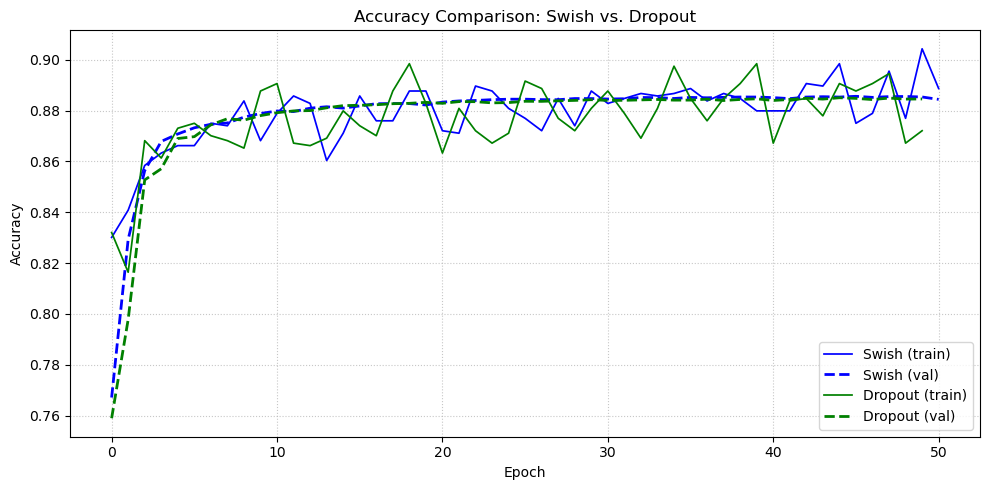

In [19]:
def plot_model_comparison(models=("swish_model", "dropout_model"),
                          metrics=("loss", "accuracy"),
                          logs_dir="logs"):
    """Compare Swish and Dropout models with training and validation curves on same axes."""

    def load_metrics(model_name):
        pattern = f"{logs_dir}/{model_name}/**/metrics.csv"
        files = glob.glob(pattern, recursive=True)

        all_data = []
        for file in files:
            version = os.path.basename(os.path.dirname(file))
            df = pd.read_csv(file)
            df['version'] = version
            df['model'] = model_name
            all_data.append(df)

        return pd.concat(all_data) if all_data else None

    model_data = {}
    for model in models:
        df = load_metrics(model)
        if df is not None:
            model_data[model] = df.groupby("epoch").last().reset_index()

    if not model_data:
        print("No data found for selected models.")
        return

    # Use reversed Paired colors and assign custom indices
    base_colors = list(plt.cm.Paired.colors[:6])[::-1]
    model_colors = {
        "swish_model": base_colors[2],    # Blue
        "dropout_model": base_colors[4],  # Green
    }
    model_colors = {
        "swish_model": "blue",    # Blue
        "dropout_model": "green",  # Green
    }

    linestyle_map = {
        'train': '-',
        'val': '--',
    }

    linewidth_map = {
        'train': 1.25,
        'val': 2,
    }

    for metric_base in metrics:
        fig, ax = plt.subplots(figsize=(10, 5))

        for model in models:
            df = model_data[model]
            for phase in ('train', 'val'):
                metric = f"{phase}_{metric_base}"
                if metric in df.columns:
                    label = f"{model.replace('_model','').capitalize()} ({phase})"
                    ax.plot(df["epoch"], df[metric],
                            linestyle=linestyle_map[phase],
                            linewidth=linewidth_map[phase],
                            color=model_colors[model],
                            label=label)

        ax.set_title(f"{metric_base.capitalize()} Comparison: Swish vs. Dropout")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_base.capitalize())
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend()
        plt.tight_layout()
        plt.show()



plot_model_comparison(logs_dir=logs_dir)


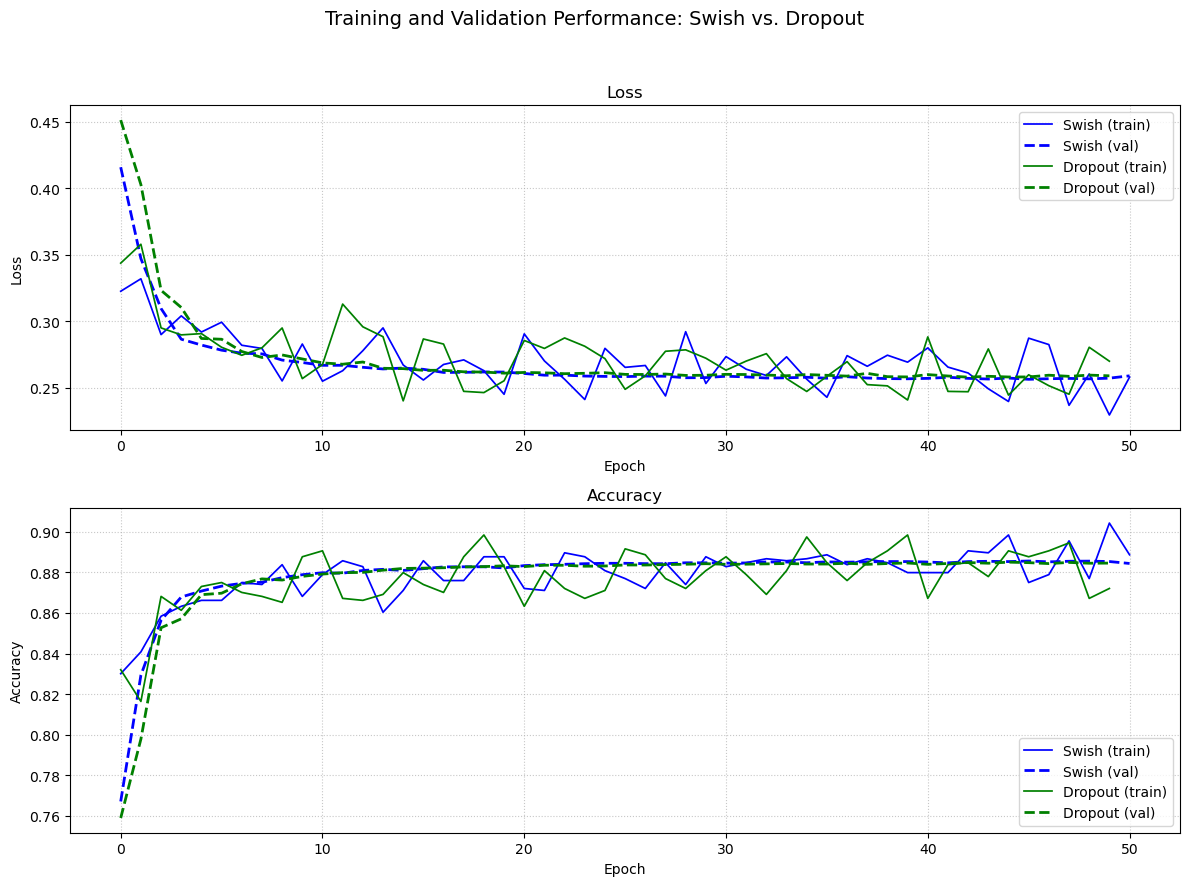

In [19]:
def plot_combined_model_comparison(models=("swish_model", "dropout_model"),
                                   logs_dir="logs"):
    """Plot training and validation loss and accuracy for two models in one figure."""

    def load_metrics(model_name):
        pattern = f"{logs_dir}/{model_name}/**/metrics.csv"
        files = glob.glob(pattern, recursive=True)

        all_data = []
        for file in files:
            version = os.path.basename(os.path.dirname(file))
            df = pd.read_csv(file)
            df['version'] = version
            df['model'] = model_name
            all_data.append(df)

        return pd.concat(all_data) if all_data else None

    model_data = {}
    for model in models:
        df = load_metrics(model)
        if df is not None:
            model_data[model] = df.groupby("epoch").last().reset_index()

    if not model_data:
        print("No data found for selected models.")
        return

    model_colors = {
        "swish_model": "blue",
        "dropout_model": "green",
    }

    linestyle_map = {
        'train': '-',
        'val': '--',
    }

    linewidth_map = {
        'train': 1.25,
        'val': 2,
    }

    # Create one figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))
    metrics = ['loss', 'accuracy']

    for ax, metric_base in zip(axes, metrics):
        for model in models:
            df = model_data[model]
            for phase in ('train', 'val'):
                metric = f"{phase}_{metric_base}"
                if metric in df.columns:
                    label = f"{model.replace('_model','').capitalize()} ({phase})"
                    ax.plot(df["epoch"], df[metric],
                            linestyle=linestyle_map[phase],
                            linewidth=linewidth_map[phase],
                            color=model_colors[model],
                            label=label)
        ax.set_title(metric_base.capitalize())
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_base.capitalize())
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend()

    fig.suptitle("Training and Validation Performance: Swish vs. Dropout", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_combined_model_comparison(logs_dir=logs_dir)



### Evaluation on the Validation Set

In [33]:
# Use the correct logs directory based on environment
if 'google.colab' in str(get_ipython()):
    # We're in Colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    logs_dir = '/content/drive/MyDrive/Colab Notebooks/logs'
else:
    # We're on local machine
    logs_dir = "logs"

# List of models to compare
model_names = ['base_model', 'dense_model', 'dropout_model', 'leaky_model', 'swish_model', 'lrscheduler_model']

# Map model names to their corresponding PyTorch Lightning class
model_classes = {
    'base_model': BaseModel,
    'dense_model': DenseModel,
    'dropout_model': DropoutModel,
    'leaky_model': LeakyModel,
    'swish_model': SwishModel,
    'lrscheduler_model': LRSchedulerModel,
}

label_map = {0: 'background: no particle', 1: 'signal: particle detected'}
label_map = {0: 'no particle', 1: 'particle detected'}
class_names = [label_map[k] for k in sorted(label_map.keys())]

# Extract true labels from test dataloader
# ----------------------------------------
# - Initialize an empty list to store batches of labels
# - Iterate over test_dataloader, ignoring input features with `_`
# - Append each y_batch (tensor of true labels) to the list
# - Concatenate all batches into a single tensor
# - Move to CPU (in case tensors are on GPU)
# - Convert to NumPy array for use with scikit-learn
# - Cleaner and safer than relying on labels returned from `trainer.predict`
all_y_true = []
for _, y_batch in test_dataloader:
    all_y_true.append(y_batch)
y_test = torch.cat(all_y_true).cpu().numpy()

# Loop through each model
results = []
confusion_matrices = []
for model_name in model_names:
    print(f"\n=== Evaluating {model_name} ===")

    # Find the latest run folder (timestamped)
    version_paths = glob.glob(f"{logs_dir}/{model_name}/*")
    version_paths = [p for p in version_paths if os.path.isdir(p)]
    if not version_paths:
        print(f"No runs found for {model_name}")
        continue
    version_paths.sort(key=os.path.getmtime, reverse=True)
    version_path = version_paths[0]
    print(f"Using run folder: {os.path.basename(version_path)}")

    # Find checkpoint
    ckpt_files = glob.glob(f"{version_path}/checkpoints/*.ckpt")
    if not ckpt_files:
        print(f"No checkpoint found for {model_name}")
        continue
    ckpt_path = ckpt_files[0]

    # Load model from checkpoint
    model_class = model_classes[model_name]
    model = model_class.load_from_checkpoint(ckpt_path)

    # Predict using trainer
    trainer = pl.Trainer(logger=False, enable_progress_bar=False)

    start_pred = time.time()
    preds = trainer.predict(model, dataloaders=test_dataloader)
    end_pred = time.time()

    predict_time_sec = end_pred - start_pred

    # Process predictions returned by trainer.predict
    # ----------------------------------------------
    # - Each item in `preds` is a (y_hat, y_true) tuple from one batch
    # - Unpack just the y_hat (predicted probabilities); ignore y_true with `_`
    # - Concatenate all prediction batches into a single tensor
    # - Move to CPU and convert to NumPy array
    # - Round probabilities to get binary class predictions (0 or 1)
    y_hat_batches, _ = zip(*preds)
    y_pred = torch.cat(y_hat_batches).cpu().numpy()
    y_pred = np.squeeze(y_pred)  # Remove any trailing singleton dimensions (e.g., [N, 1] → [N])
    y_pred_class = np.round(y_pred)

    metrics_dict = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred_class),
        "precision": precision_score(y_test, y_pred_class),
        "recall": recall_score(y_test, y_pred_class),
        "f1": f1_score(y_test, y_pred_class),
        # "training_time_min": training_time.get(model_name, None),
        "predict_time_sec": predict_time_sec,
    }
    results.append(metrics_dict)

    # Classification report
    print(f"\nClassification Report: {model_name}")
    print(classification_report(y_test, y_pred_class, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_class)
    print(f"\nConfusion Matrix: {model_name}")
    print(cm)
    confusion_matrices.append((model_name, cm))

    # Display
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    # disp.plot(cmap=plt.cm.Blues, colorbar=False)
    # plt.title(f"Confusion Matrix: {model_name}")
    # plt.show()


Mounted at /content/drive


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Evaluating base_model ===
Using run folder: 20250713_005255

Classification Report: base_model
              precision    recall  f1-score   support

         0.0     0.8872    0.8300    0.8576    699824
         1.0     0.8404    0.8945    0.8666    700176

    accuracy                         0.8623   1400000
   macro avg     0.8638    0.8623    0.8621   1400000
weighted avg     0.8638    0.8623    0.8621   1400000


Confusion Matrix: base_model
[[580873 118951]
 [ 73873 626303]]

=== Evaluating dense_model ===
Using run folder: 20250713_015316


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Classification Report: dense_model
              precision    recall  f1-score   support

         0.0     0.9056    0.8507    0.8773    699824
         1.0     0.8593    0.9114    0.8846    700176

    accuracy                         0.8811   1400000
   macro avg     0.8825    0.8811    0.8810   1400000
weighted avg     0.8825    0.8811    0.8810   1400000



...


Classification Report: leaky_model
              precision    recall  f1-score   support

         0.0     0.8975    0.8665    0.8817    699824
         1.0     0.8710    0.9011    0.8858    700176

    accuracy                         0.8838   1400000
   macro avg     0.8843    0.8838    0.8838   1400000
weighted avg     0.8843    0.8838    0.8838   1400000


Confusion Matrix: leaky_model
[[606410  93414]
 [ 69264 630912]]

=== Evaluating swish_model ===
Using run folder: 20250713_132451


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Classification Report: swish_model
              precision    recall  f1-score   support

         0.0     0.8948    0.8712    0.8828    699824
         1.0     0.8745    0.8976    0.8859    700176

    accuracy                         0.8844   1400000
   macro avg     0.8847    0.8844    0.8844   1400000
weighted avg     0.8847    0.8844    0.8844   1400000


Confusion Matrix: swish_model
[[609660  90164]
 [ 71685 628491]]

=== Evaluating lrscheduler_model ===
Using run folder: 20250714_212224


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Classification Report: lrscheduler_model
              precision    recall  f1-score   support

         0.0     0.9009    0.8637    0.8819    699824
         1.0     0.8692    0.9050    0.8868    700176

    accuracy                         0.8844   1400000
   macro avg     0.8851    0.8844    0.8843   1400000
weighted avg     0.8851    0.8844    0.8844   1400000


Confusion Matrix: lrscheduler_model
[[604467  95357]
 [ 66483 633693]]



Summary Table:
               model  accuracy  precision    recall        f1  \
2      dropout_model  0.884564   0.867677  0.907598  0.887188   
5  lrscheduler_model  0.884400   0.869204  0.905048  0.886764   
4        swish_model  0.884394   0.874538  0.897619  0.885928   
3        leaky_model  0.883801   0.871033  0.901076  0.885800   
1        dense_model  0.881068   0.859311  0.911415  0.884596   
0         base_model  0.862269   0.840389  0.894494  0.866597   

   predict_time_sec  
2         14.644565  
5         15.118198  
4         15.021345  
3         14.912828  
1         14.919814  
0         13.831445  


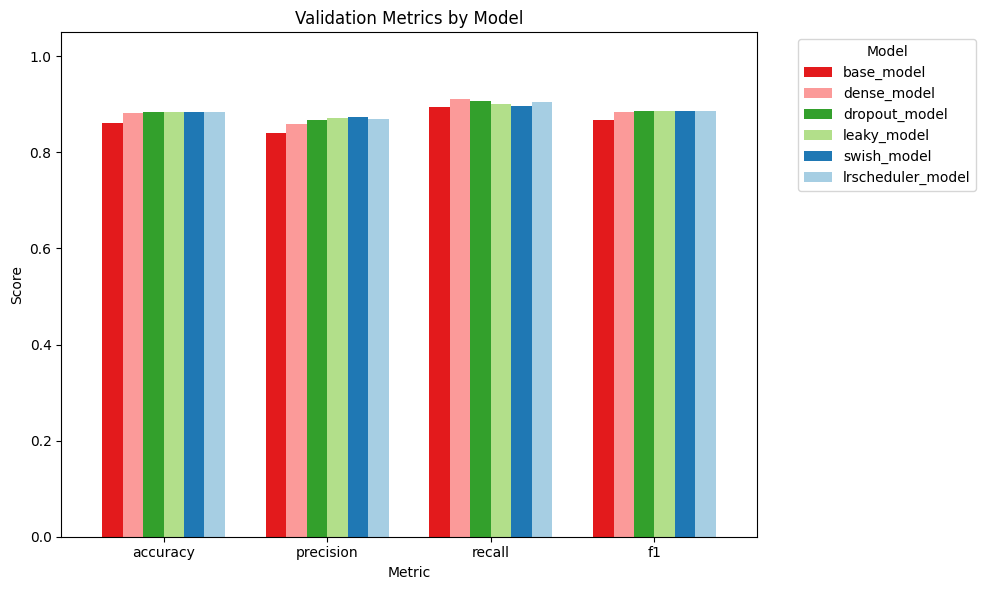

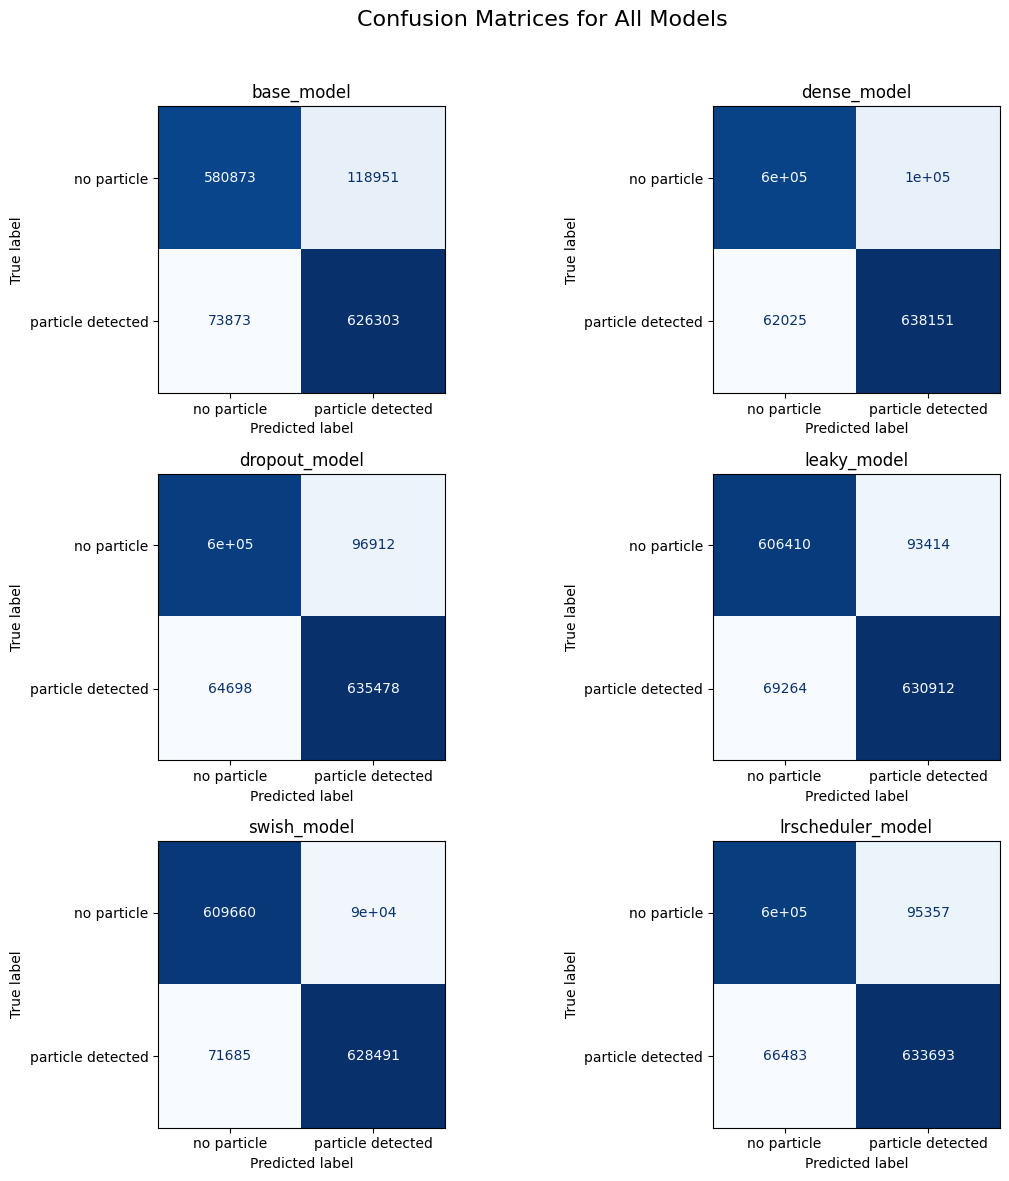

In [35]:
label_map = {0: 'no particle', 1: 'particle detected'}
class_names = [label_map[k] for k in sorted(label_map.keys())]

# After evaluating all models
df_results = pd.DataFrame(results)
df_results.sort_values(by="accuracy", ascending=False, inplace=True)
df_results.to_csv("model_comparison.csv", index=False)

# Display
print("\nSummary Table:")
print(df_results)

metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

# Desired model order (to match color list)
model_order = ['base_model', 'dense_model', 'dropout_model', 'leaky_model', 'swish_model', 'lrscheduler_model']

# Reorder df_results to match that model order
df_results = df_results.set_index("model").loc[model_order].reset_index()

# Transpose so metrics are on the x-axis and models become columns
df_plot = df_results.set_index("model")[metrics_to_plot].T

# Define your custom reversed colors (one per model)
colors = list(plt.cm.Paired.colors[:6])[::-1]  # Make sure it's a list in correct order

# Plot
ax = df_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=colors,
    width=0.75,
)

# Format
plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("Validation Metrics by Model")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Turn list into dict for easy lookup
conf_matrix_dict = dict(confusion_matrices)

# Force same order
confusion_matrices_ordered = [(model, conf_matrix_dict[model]) for model in model_order]

# Plot Confusion Matrices
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False)
    axes[i].set_title(model_name)

for j in range(len(confusion_matrices), 6):
    fig.delaxes(axes[j])

fig.suptitle("Confusion Matrices for All Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Evaluation on the (True HEPMASS) Testing Set for Comparison

`all_test.csv`

In [36]:
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/Colab Notebooks'
else:
    base_path = os.getcwd()

print("Base path:", base_path)
data_path = os.path.join(base_path, 'data', 'all_test.csv.gz')

raw_test_data = pd.read_csv(data_path)
print(raw_test_data.shape)
raw_test_data.info()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base path: /content/drive/MyDrive/Colab Notebooks
(3500000, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500000 entries, 0 to 3499999
Data columns (total 29 columns):
 #   Column   Dtype  
---  ------   -----  
 0   # label  float64
 1   f0       float64
 2   f1       float64
 3   f2       float64
 4   f3       float64
 5   f4       float64
 6   f5       float64
 7   f6       float64
 8   f7       float64
 9   f8       float64
 10  f9       float64
 11  f10      float64
 12  f11      float64
 13  f12      float64
 14  f13      float64
 15  f14      float64
 16  f15      float64
 17  f16      float64
 18  f17      float64
 19  f18      float64
 20  f19      float64
 21  f20      float64
 22  f21      float64
 23  f22      float64
 24  f23      float64
 25  f24      float64
 26  f25      float64
 27  f26      float64
 28  mass     float64
dtypes: floa

In [37]:
raw_test_data.columns

Index(['# label', 'f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9',
       'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19',
       'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'mass'],
      dtype='object')

In [38]:
# Convert datatypes for efficiency
converted_test_data = raw_test_data.copy()

converted_test_data = converted_test_data.astype('float32')

converted_test_data.info()

# Make X and y
X_new = converted_test_data.drop(columns='# label')
y_new = converted_test_data['# label']

# Fit scaler only on training data
X_new_scaled = scaler.transform(X_new) # only transform, scaler already instantiated

X_new_scaled.shape, y_new.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500000 entries, 0 to 3499999
Data columns (total 29 columns):
 #   Column   Dtype  
---  ------   -----  
 0   # label  float32
 1   f0       float32
 2   f1       float32
 3   f2       float32
 4   f3       float32
 5   f4       float32
 6   f5       float32
 7   f6       float32
 8   f7       float32
 9   f8       float32
 10  f9       float32
 11  f10      float32
 12  f11      float32
 13  f12      float32
 14  f13      float32
 15  f14      float32
 16  f15      float32
 17  f16      float32
 18  f17      float32
 19  f18      float32
 20  f19      float32
 21  f20      float32
 22  f21      float32
 23  f22      float32
 24  f23      float32
 25  f24      float32
 26  f25      float32
 27  f26      float32
 28  mass     float32
dtypes: float32(29)
memory usage: 387.2 MB


((3500000, 28), (3500000,))

In [43]:
test_data = HepmassDataset(X_new_scaled,y_new)

# Sanity check for data format
for data_in, target in test_data:
    print(data_in)
    print(target)
    break

# Create dataloaders
if colab:
    newtest_dataloader = DataLoader(test_data, batch_size=1024, shuffle=False,num_workers=11)
else:
    newtest_dataloader = DataLoader(test_data, batch_size=1024, shuffle=False,num_workers=0)

tensor([ 0.0779,  0.0126,  0.9121, -0.1018, -0.2336, -1.0558, -1.0072, -1.0706,
        -0.6145,  0.7597, -0.9484, -0.5292,  1.2351,  0.8591, -0.2490, -0.4053,
        -1.5585, -0.8197, -1.3845,  0.0679,  1.3722, -0.5739, -1.3664, -0.4865,
         1.5108, -0.5831, -1.3290, -1.4151])
tensor(0.)


In [44]:
# Use the correct logs directory based on environment
if 'google.colab' in str(get_ipython()):
    # We're in Colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    logs_dir = '/content/drive/MyDrive/Colab Notebooks/logs'
else:
    # We're on local machine
    logs_dir = "logs"

# List of models to compare
model_names = ['base_model', 'dense_model', 'dropout_model', 'leaky_model', 'swish_model', 'lrscheduler_model']

# Map model names to their corresponding PyTorch Lightning class
model_classes = {
    'base_model': BaseModel,
    'dense_model': DenseModel,
    'dropout_model': DropoutModel,
    'leaky_model': LeakyModel,
    'swish_model': SwishModel,
    'lrscheduler_model': LRSchedulerModel,
}

label_map = {0: 'no particle', 1: 'particle detected'}
class_names = [label_map[k] for k in sorted(label_map.keys())]

# Extract true labels from test dataloader
# ----------------------------------------
# - Initialize an empty list to store batches of labels
# - Iterate over test_dataloader, ignoring input features with `_`
# - Append each y_batch (tensor of true labels) to the list
# - Concatenate all batches into a single tensor
# - Move to CPU (in case tensors are on GPU)
# - Convert to NumPy array for use with scikit-learn
# - Cleaner and safer than relying on labels returned from `trainer.predict`
all_y_true = []
for _, y_batch in newtest_dataloader:
    all_y_true.append(y_batch)
y_test = torch.cat(all_y_true).cpu().numpy()

# Loop through each model
results = []
confusion_matrices = []
for model_name in model_names:
    print(f"\n=== Evaluating {model_name} ===")

    # Find the latest run folder (timestamped)
    version_paths = glob.glob(f"{logs_dir}/{model_name}/*")
    version_paths = [p for p in version_paths if os.path.isdir(p)]
    if not version_paths:
        print(f"No runs found for {model_name}")
        continue
    version_paths.sort(key=os.path.getmtime, reverse=True)
    version_path = version_paths[0]
    print(f"Using run folder: {os.path.basename(version_path)}")

    # Find checkpoint
    ckpt_files = glob.glob(f"{version_path}/checkpoints/*.ckpt")
    if not ckpt_files:
        print(f"No checkpoint found for {model_name}")
        continue
    ckpt_path = ckpt_files[0]

    # Load model from checkpoint
    model_class = model_classes[model_name]
    model = model_class.load_from_checkpoint(ckpt_path)

    # Predict using trainer
    trainer = pl.Trainer(logger=False, enable_progress_bar=False)

    start_pred = time.time()
    preds = trainer.predict(model, dataloaders=newtest_dataloader)
    end_pred = time.time()

    predict_time_sec = end_pred - start_pred

    # Process predictions returned by trainer.predict
    # ----------------------------------------------
    # - Each item in `preds` is a (y_hat, y_true) tuple from one batch
    # - Unpack just the y_hat (predicted probabilities); ignore y_true with `_`
    # - Concatenate all prediction batches into a single tensor
    # - Move to CPU and convert to NumPy array
    # - Round probabilities to get binary class predictions (0 or 1)
    y_hat_batches, _ = zip(*preds)
    y_pred = torch.cat(y_hat_batches).cpu().numpy()
    y_pred = np.squeeze(y_pred)  # Remove any trailing singleton dimensions (e.g., [N, 1] → [N])
    y_pred_class = np.round(y_pred)

    metrics_dict = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred_class),
        "precision": precision_score(y_test, y_pred_class),
        "recall": recall_score(y_test, y_pred_class),
        "f1": f1_score(y_test, y_pred_class),
        # "training_time_min": training_time.get(model_name, None),
        "predict_time_sec": predict_time_sec,
    }
    results.append(metrics_dict)

    # Classification report
    print(f"\nClassification Report: {model_name}")
    print(classification_report(y_test, y_pred_class, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_class)
    print(f"\nConfusion Matrix: {model_name}")
    print(cm)
    confusion_matrices.append((model_name, cm))

    # Display
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    # disp.plot(cmap=plt.cm.Blues, colorbar=False)
    # plt.title(f"Confusion Matrix: {model_name}")
    # plt.show()


Mounted at /content/drive


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Evaluating base_model ===
Using run folder: 20250713_005255

Classification Report: base_model
              precision    recall  f1-score   support

         0.0     0.5632    0.9420    0.7049   1750755
         1.0     0.8223    0.2688    0.4051   1749245

    accuracy                         0.6055   3500000
   macro avg     0.6927    0.6054    0.5550   3500000
weighted avg     0.6927    0.6055    0.5551   3500000



INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Confusion Matrix: base_model
[[1649148  101607]
 [1279109  470136]]

=== Evaluating dense_model ===
Using run folder: 20250713_015316

Classification Report: dense_model
              precision    recall  f1-score   support

         0.0     0.5267    0.5359    0.5313   1750755
         1.0     0.5272    0.5180    0.5226   1749245

    accuracy                         0.5270   3500000
   macro avg     0.5270    0.5270    0.5269   3500000
weighted avg     0.5270    0.5270    0.5269   3500000



...

              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000   1750755
         1.0     0.4998    1.0000    0.6665   1749245

    accuracy                         0.4998   3500000
   macro avg     0.2499    0.5000    0.3332   3500000
weighted avg     0.2498    0.4998    0.3331   3500000



INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Confusion Matrix: leaky_model
[[      0 1750755]
 [      0 1749245]]

=== Evaluating swish_model ===
Using run folder: 20250713_132451

Classification Report: swish_model
              precision    recall  f1-score   support

         0.0     0.8095    0.7557    0.7817   1750755
         1.0     0.7707    0.8221    0.7956   1749245

    accuracy                         0.7889   3500000
   macro avg     0.7901    0.7889    0.7886   3500000
weighted avg     0.7902    0.7889    0.7886   3500000



INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Confusion Matrix: swish_model
[[1323026  427729]
 [ 311260 1437985]]

=== Evaluating lrscheduler_model ===
Using run folder: 20250714_212224

Classification Report: lrscheduler_model
              precision    recall  f1-score   support

         0.0     0.4192    0.6465    0.5086   1750755
         1.0     0.2266    0.1037    0.1423   1749245

    accuracy                         0.3752   3500000
   macro avg     0.3229    0.3751    0.3255   3500000
weighted avg     0.3230    0.3752    0.3255   3500000


Confusion Matrix: lrscheduler_model
[[1131819  618936]
 [1567877  181368]]



Summary Table (with all_test Testing Set):
               model  accuracy  precision    recall        f1  \
4        swish_model  0.788860   0.770742  0.822060  0.795575   
0         base_model  0.605510   0.822286  0.268765  0.405117   
2      dropout_model  0.592599   0.942786  0.196789  0.325613   
1        dense_model  0.526965   0.527236  0.518035  0.522595   
3        leaky_model  0.499784   0.499784  1.000000  0.666475   
5  lrscheduler_model  0.375196   0.226624  0.103684  0.142275   

   predict_time_sec  
4         14.167493  
0         14.122765  
2         16.088975  
1         15.075539  
3         17.201344  
5         15.653072  


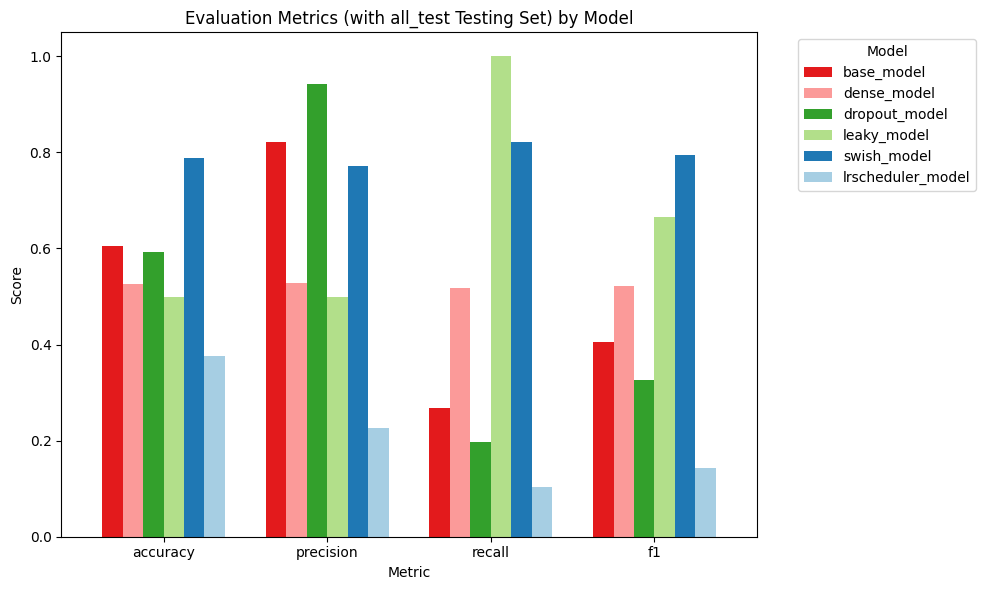

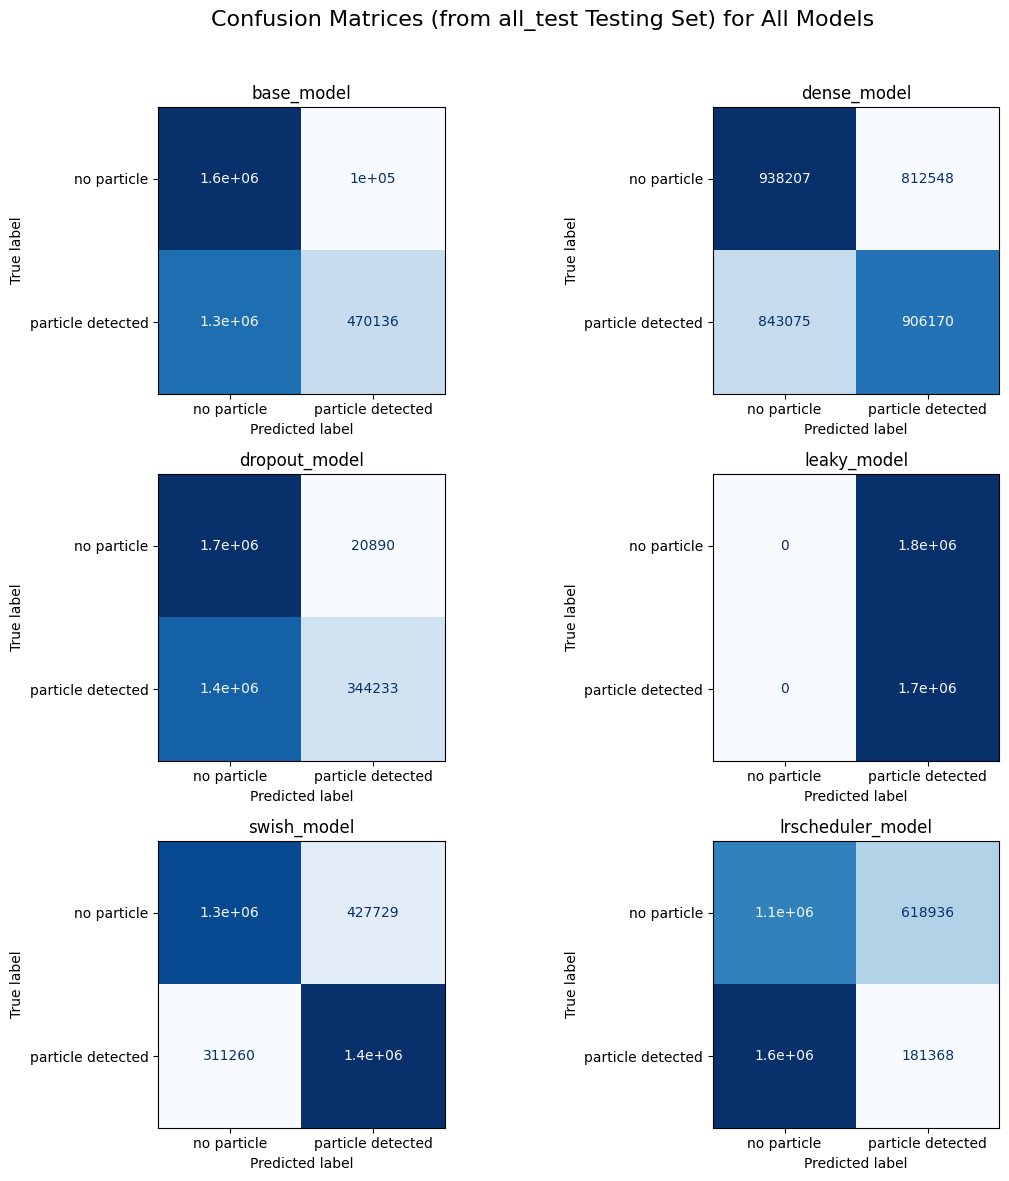

In [45]:
label_map = {0: 'no particle', 1: 'particle detected'}
class_names = [label_map[k] for k in sorted(label_map.keys())]

# After evaluating all models
df_results = pd.DataFrame(results)
df_results.sort_values(by="accuracy", ascending=False, inplace=True)
df_results.to_csv("model_comparison_all_test.csv", index=False)

# Display
print("\nSummary Table (with all_test Testing Set):")
print(df_results)

metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

# Desired model order (to match color list)
model_order = ['base_model', 'dense_model', 'dropout_model', 'leaky_model', 'swish_model', 'lrscheduler_model']

# Reorder df_results to match that model order
df_results = df_results.set_index("model").loc[model_order].reset_index()

# Transpose so metrics are on the x-axis and models become columns
df_plot = df_results.set_index("model")[metrics_to_plot].T

# Define your custom reversed colors (one per model)
colors = list(plt.cm.Paired.colors[:6])[::-1]  # Make sure it's a list in correct order

# Plot
ax = df_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=colors,
    width=0.75,
)

# Format
plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("Evaluation Metrics (with all_test Testing Set) by Model")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Turn list into dict for easy lookup
conf_matrix_dict = dict(confusion_matrices)

# Force same order
confusion_matrices_ordered = [(model, conf_matrix_dict[model]) for model in model_order]

# Plot Confusion Matrices
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False)
    axes[i].set_title(model_name)

for j in range(len(confusion_matrices), 6):
    fig.delaxes(axes[j])

fig.suptitle("Confusion Matrices (from all_test Testing Set) for All Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()